<a href="https://colab.research.google.com/github/EkaMiharja/SMOTE_LightGBM_V1/blob/hasil-3/SMOTELightBGM_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [4]:
# NumPy
# Digunakan untuk operasi numerik dan pengolahan array
import numpy as np

# Pandas
# Digunakan untuk membaca, mengolah, dan menganalisis dataset
import pandas as pd

# Matplotlib
# Digunakan untuk membuat visualisasi data
import matplotlib.pyplot as plt

# Seaborn
# Digunakan untuk membuat visualisasi statistik
import seaborn as sns

# Scikit-learn
# Digunakan untuk membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split

# Scikit-learn
# Digunakan untuk mengevaluasi performa model klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# LightGBM
# Digunakan untuk membuat dan melatih model Machine Learning untuk klasifikasi traffic jaringan
from lightgbm import LGBMClassifier

# Imbalanced-learn
# Digunakan untuk menangani ketidakseimbangan jumlah kelas pada dataset menggunakan metode SMOTE
from imblearn.over_sampling import SMOTE

## 2. Load Dataset

In [5]:
# Membaca dataset CIC-IDS2018 dari file CSV
df = pd.read_csv("/content/cic.csv")

# Menampilkan 5 baris pertama dataset
print(df.head())

# Menampilkan ukuran dataset
# Hasil: (jumlah baris, 80 kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan jumlah kolom
print("Jumlah kolom:", len(df.columns))

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

## 3. Cleaning Dataset

# a.Melihat Informasi Dataset

In [6]:
# Digunakan untuk melihat jumlah data, nama kolom, dan tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

# b.Mengecek missing value

In [7]:
# Digunakan untuk mengetahui apakah terdapat nilai kosong pada setiap kolom
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64


# c.Menghapus data duplikat

In [8]:
# Data yang sama tidak diperlukan untuk proses training
df = df.drop_duplicates()

print("\nUkuran dataset setelah menghapus duplikat:")
print(df.shape)


Ukuran dataset setelah menghapus duplikat:
(822947, 80)


# d.Mengecek nilai tak hingga

In [9]:
print("\nJumlah nilai Infinity:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


Jumlah nilai Infinity:
5365


# e.Mengganti nilai Infinity menjadi NaN


In [10]:
df = df.replace([np.inf, -np.inf], np.nan)

# f.Mengecek kembali missing value


In [11]:
# Setelah nilai Infinity diubah menjadi NaN
print("\nMissing Value setelah pengecekan Infinity:")
print(df.isnull().sum().sum())


Missing Value setelah pengecekan Infinity:
7642


# g.Hapus missing value

In [12]:
# Dilakukan setelah Infinity diubah menjadi NaN
df = df.dropna()

print("\nUkuran dataset setelah membersihkan missing value:")
print(df.shape)


Ukuran dataset setelah membersihkan missing value:
(819126, 80)


# h.Mengecek kembali kondisi dataset


In [13]:
# untuk memastikan dataset sudah bersih
print("\nInformasi dataset setelah cleaning:")
df.info()


Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 819126 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           819126 non-null  int64  
 1   Protocol           819126 non-null  int64  
 2   Timestamp          819126 non-null  object 
 3   Flow Duration      819126 non-null  int64  
 4   Tot Fwd Pkts       819126 non-null  int64  
 5   Tot Bwd Pkts       819126 non-null  int64  
 6   TotLen Fwd Pkts    819126 non-null  int64  
 7   TotLen Bwd Pkts    819126 non-null  int64  
 8   Fwd Pkt Len Max    819126 non-null  int64  
 9   Fwd Pkt Len Min    819126 non-null  int64  
 10  Fwd Pkt Len Mean   819126 non-null  float64
 11  Fwd Pkt Len Std    819126 non-null  float64
 12  Bwd Pkt Len Max    819126 non-null  int64  
 13  Bwd Pkt Len Min    819126 non-null  int64  
 14  Bwd Pkt Len Mean   819126 non-null  float64
 15  Bwd Pkt Len Std   

## 4. EDA


# a.Melihat statistik deskriptif


In [14]:
# Digunakan untuk melihat nilai rata-rata, minimum,
# maksimum, dan statistik lainnya dari fitur numerik
print("Statistik Deskriptif:")
print(df.describe())

Statistik Deskriptif:
            Dst Port       Protocol  Flow Duration   Tot Fwd Pkts  \
count  819126.000000  819126.000000   8.191260e+05  819126.000000   
mean     6003.351760       8.697304   8.007824e+06       7.658836   
std     15799.742162       4.886142   1.425916e+09      50.228038   
min         0.000000       0.000000  -9.190110e+11       1.000000   
25%        53.000000       6.000000   3.170000e+02       1.000000   
50%        80.000000       6.000000   4.956450e+04       2.000000   
75%       445.000000      17.000000   1.755662e+06       9.000000   
max     65533.000000      17.000000   1.200000e+08    5115.000000   

        Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
count  819126.000000     8.191260e+05     8.191260e+05    819126.000000   
mean        8.957209     5.734126e+02     5.788421e+03       223.405172   
std       118.591371     1.780137e+04     1.713914e+05       308.277377   
min         0.000000     0.000000e+00     0.000000e+00  

# b.Melihat jumlah data pada setiap label

In [15]:
# Digunakan untuk mengetahui jenis traffic
# dan jumlah masing-masing kelas
print("\nDistribusi Label:")
print(df["Label"].value_counts())


Distribusi Label:
Label
Benign            662458
SSH-Bruteforce    117322
FTP-BruteForce     39346
Name: count, dtype: int64


# c.Melihat persentase setiap label


In [16]:
# Digunakan untuk mengetahui proporsi setiap kelas
print("\nPersentase Label:")
print(df["Label"].value_counts(normalize=True) * 100)


Persentase Label:
Label
Benign            80.873761
SSH-Bruteforce    14.322827
FTP-BruteForce     4.803412
Name: proportion, dtype: float64


# d.Visualisasi distribusi label


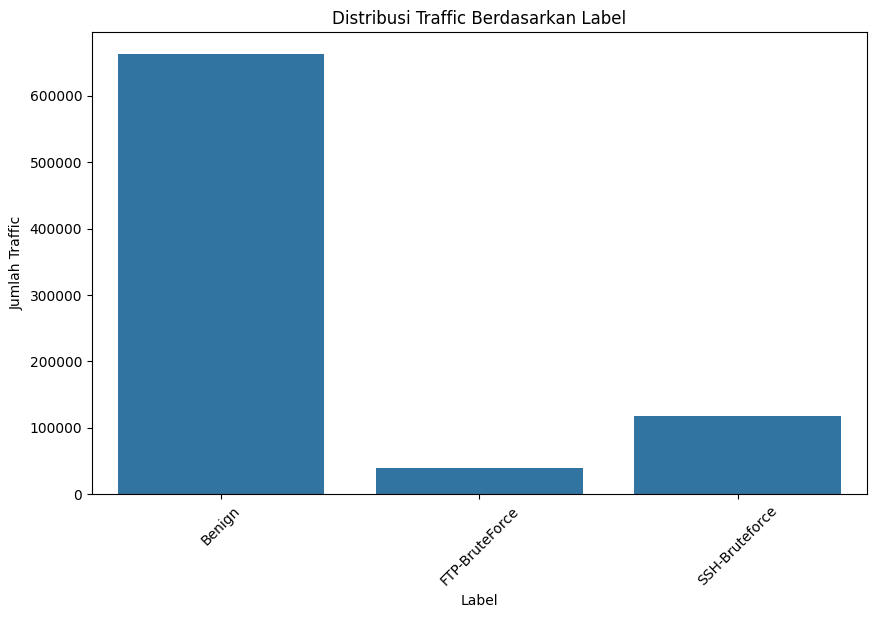

In [17]:
# Digunakan untuk melihat perbandingan jumlah
# traffic pada setiap kelas
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Label")

plt.title("Distribusi Traffic Berdasarkan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Traffic")
plt.xticks(rotation=45)

plt.show()

# e.Melihat distribusi fitur numerik

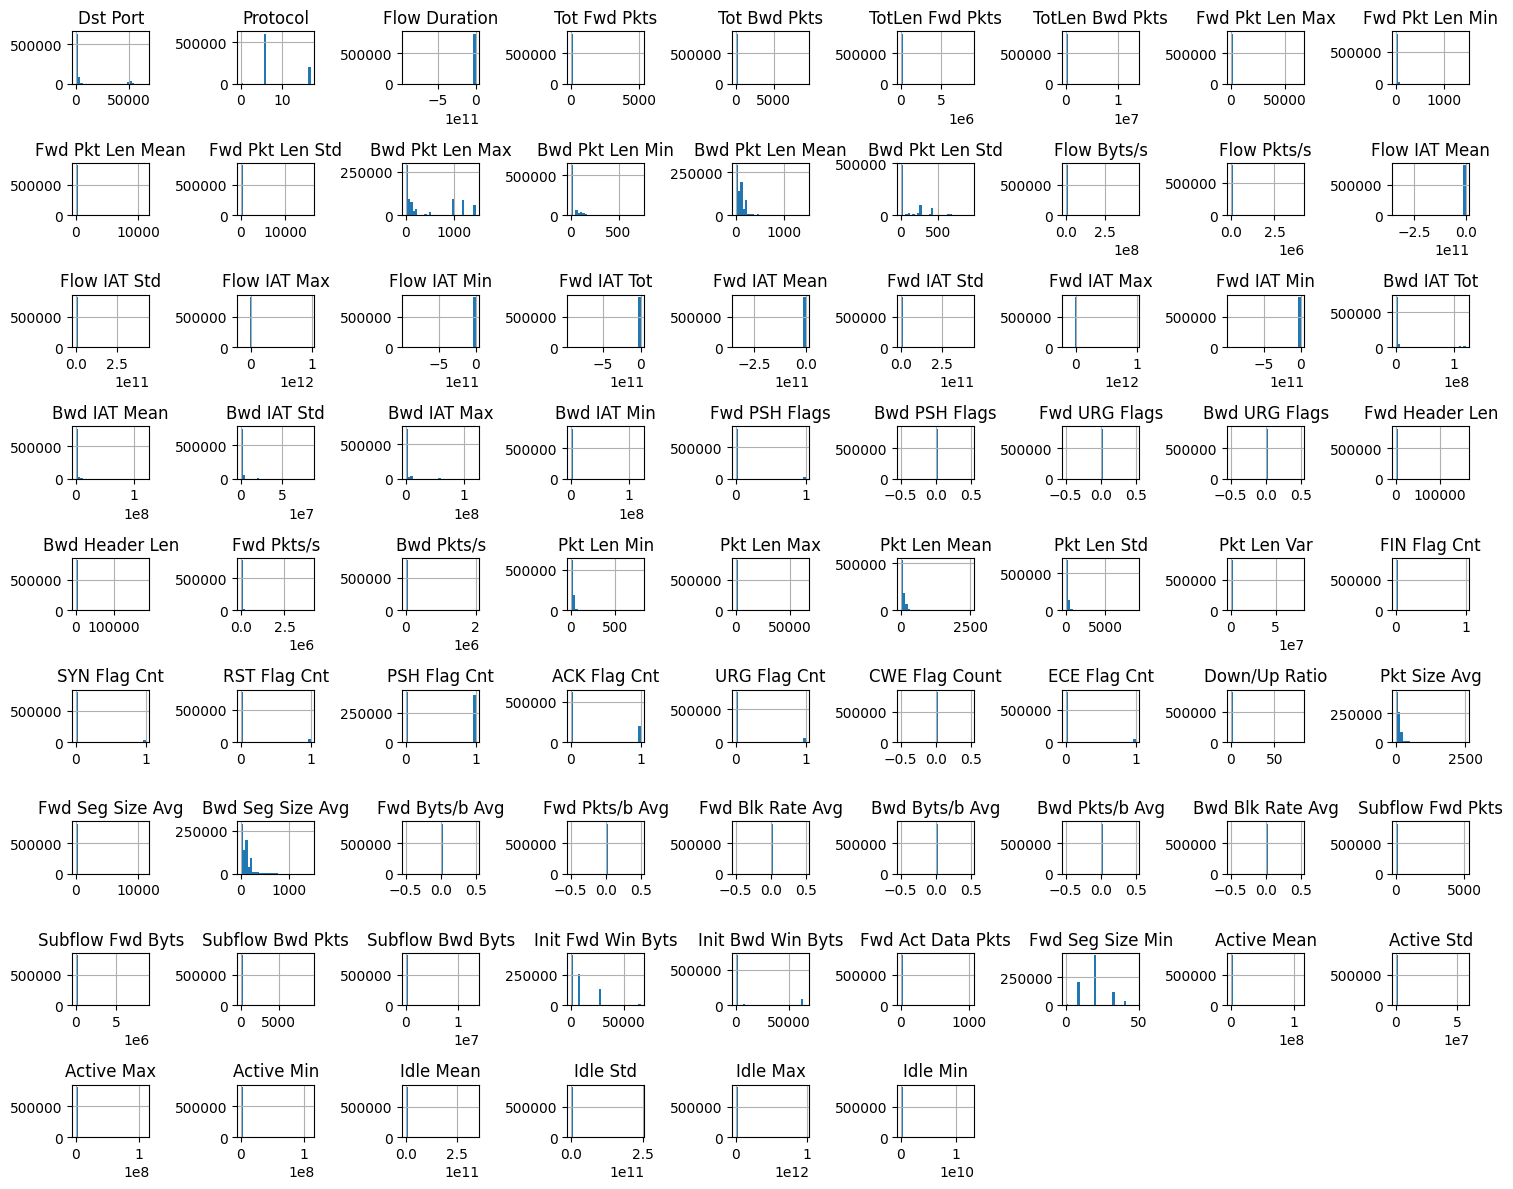

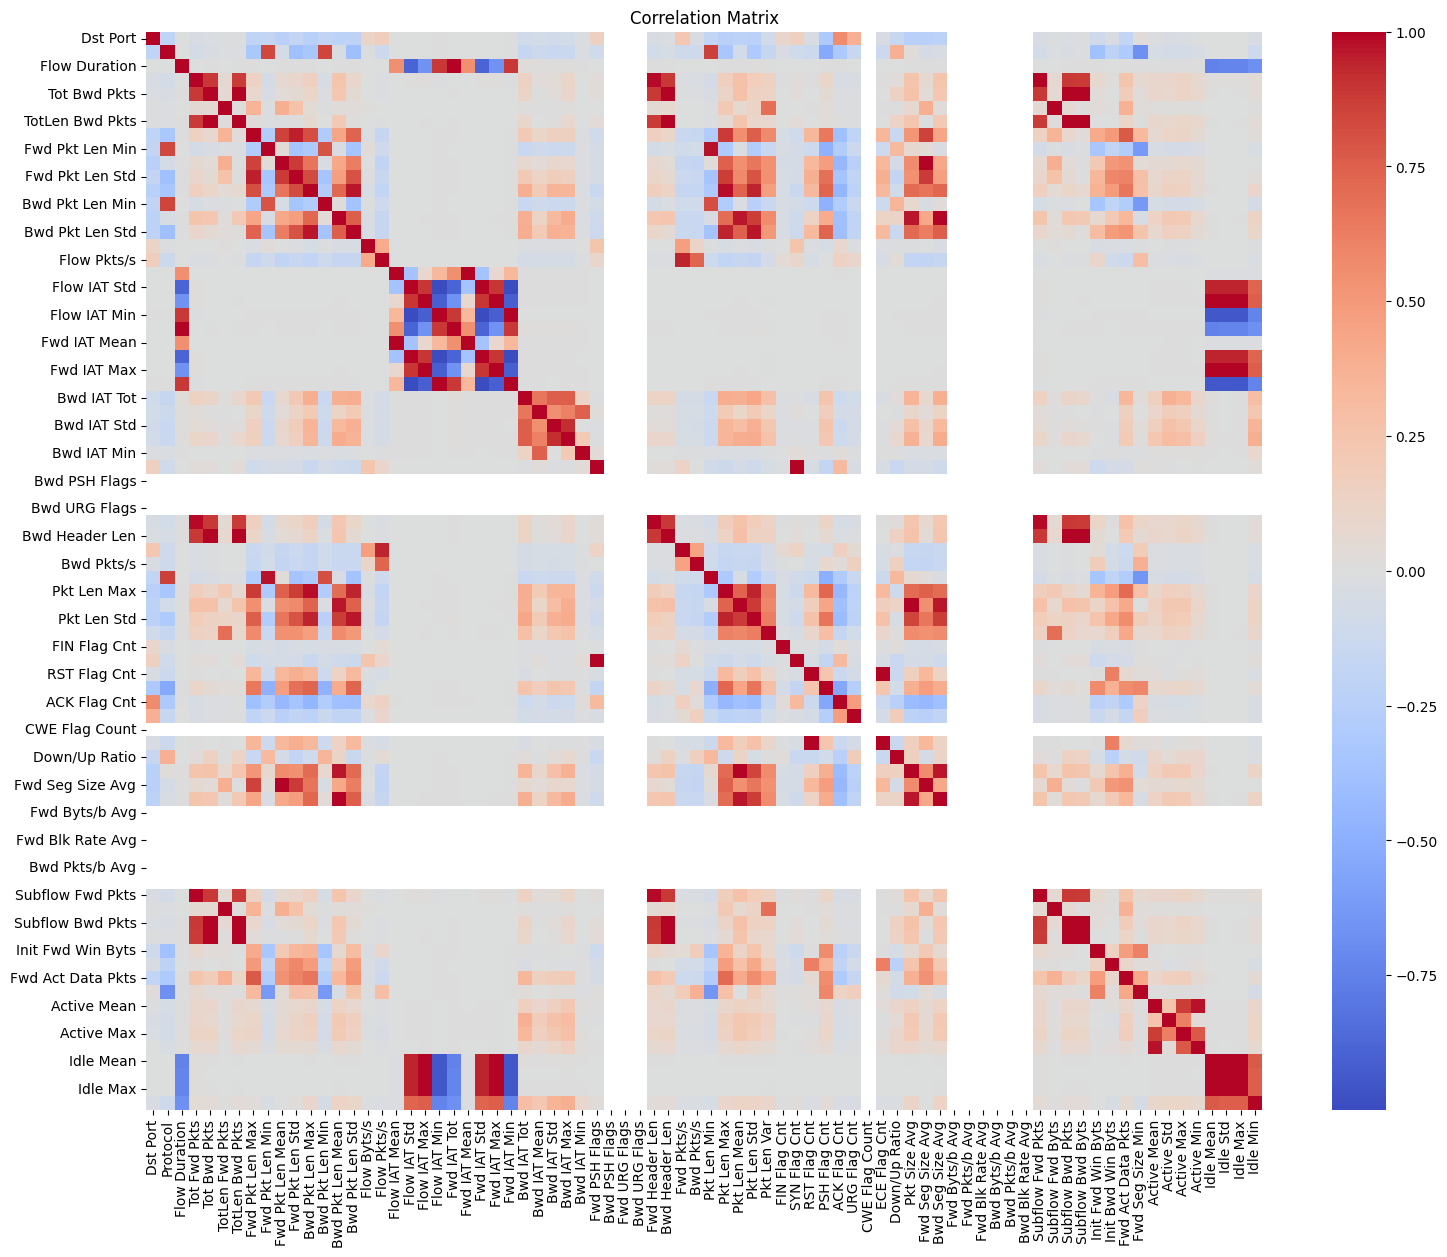

In [18]:
# Digunakan untuk mengetahui karakteristik
# beberapa fitur numerik dalam dataset
df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()


# 4.6 Melihat korelasi antar fitur numerik
# Digunakan untuk mengetahui hubungan antar fitur
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 5. Menentukan Fitur dan  Target


# a.Melihat seluruh label yang tersedia


In [19]:
# Digunakan untuk mengetahui nama label pada dataset
print("Label yang tersedia:")
print(df["Label"].unique())

Label yang tersedia:
['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']


# b.Menentukan label yang digunakan



In [20]:

# Normal dan Brute Force SSH
# dari df["Label"].unique()
target_labels = [
    "Benign",
    "SSH-Bruteforce"
]


# c.Mengambil data yang hanya memiliki label


In [21]:
# Normal dan Brute Force SSH
df_model = df[df["Label"].isin(target_labels)].copy()

# d.Mengecek kembali distribusi label

In [22]:
print("\nDistribusi label setelah filtering:")
print(df_model["Label"].value_counts())



Distribusi label setelah filtering:
Label
Benign            662458
SSH-Bruteforce    117322
Name: count, dtype: int64


# e.Menentukan target (y)


In [23]:
# Label merupakan target yang ingin diprediksi oleh model
y = df_model["Label"]

# f.Menentukan fitur (X)


In [24]:
# Timestamp dan Label tidak digunakan sebagai fitur
X = df_model.drop(columns=["Label", "Timestamp"])

# g.Melihat jumlah fitur yang digunakan


In [25]:
print("\nJumlah fitur:", X.shape[1])

# Melihat nama fitur
print("\nNama fitur:")
print(X.columns.tolist())


Jumlah fitur: 78

Nama fitur:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk 

## 6. Preprocessing

# a.Membersihkan nama kolom


In [26]:
# Menghilangkan spasi yang mungkin terdapat pada
# bagian awal atau akhir nama kolom
X.columns = X.columns.str.strip()

# b.Mengecek tipe data fitur


In [27]:
# Memastikan fitur dapat digunakan oleh model
print("Tipe data fitur:")
print(X.dtypes)

Tipe data fitur:
Dst Port           int64
Protocol           int64
Flow Duration      int64
Tot Fwd Pkts       int64
Tot Bwd Pkts       int64
                  ...   
Active Min         int64
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Length: 78, dtype: object


# c.Mengubah label menjadi angka


In [28]:
# Benign dan Brute Force SSH akan diubah menjadi
# nilai numerik agar dapat diproses oleh model
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

# d.Melihat hasil encoding label


In [29]:
print("\nMapping label:")
for label, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} = {encoded}")


Mapping label:
Benign = 0
SSH-Bruteforce = 1


# e.Melihat bentuk akhir X dan y


In [30]:
print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)


Ukuran X: (779780, 78)
Ukuran y: (779780,)


## 7. Train Test Split

# a.Membagi dataset menjadi data training dan testing

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# b.Menampilkan ukuran masing-masing data


In [32]:
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (623824, 78)
Ukuran X_test : (155956, 78)
Ukuran y_train: (623824,)
Ukuran y_test : (155956,)


# c.Mengecek distribusi label pada data training

In [33]:

print("\nDistribusi label pada data training:")
print(pd.Series(y_train).value_counts())



Distribusi label pada data training:
0    529966
1     93858
Name: count, dtype: int64


# d.Mengecek distribusi label pada data testing


In [34]:
print("\nDistribusi label pada data testing:")
print(pd.Series(y_test).value_counts())


Distribusi label pada data testing:
0    132492
1     23464
Name: count, dtype: int64


## 8. Menangani Imbalanced data dengan SMOTE

# a.Melihat distribusi kelas sebelum SMOTE


In [35]:
print("Distribusi kelas sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

Distribusi kelas sebelum SMOTE:
0    529966
1     93858
Name: count, dtype: int64


# b.Membuat objek SMOTE


In [36]:
# random_state digunakan agar hasil dapat direproduksi
smote = SMOTE(random_state=42)

# c.Melakukan SMOTE pada data training

In [37]:
# X_train dan y_train yang diproses
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# d.Melihat distribusi kelas setelah SMOTE

In [38]:
print("\nDistribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())



Distribusi kelas setelah SMOTE:
0    529966
1    529966
Name: count, dtype: int64


# e.Melihat ukuran data setelah SMOTE

In [39]:
print("\nUkuran X_train sebelum SMOTE:", X_train.shape)
print("Ukuran X_train setelah SMOTE:", X_train_smote.shape)

print("\nUkuran y_train sebelum SMOTE:", y_train.shape)
print("Ukuran y_train setelah SMOTE:", y_train_smote.shape)


Ukuran X_train sebelum SMOTE: (623824, 78)
Ukuran X_train setelah SMOTE: (1059932, 78)

Ukuran y_train sebelum SMOTE: (623824,)
Ukuran y_train setelah SMOTE: (1059932,)


## 9. Membuat Model LightGBM

# a.Membuat model LightGBM untuk klasifikasi

In [40]:
model_lgbm = LGBMClassifier(
    objective="binary",      # Klasifikasi 2 kelas
    n_estimators=100,        # Jumlah decision tree
    learning_rate=0.1,      # Kecepatan model dalam belajar
    max_depth=6,            # Kedalaman Tree
    random_state=42          # Agar hasil dapat direproduksi
)

In [41]:
# Menampilkan konfigurasi model
print(model_lgbm)

LGBMClassifier(max_depth=6, objective='binary', random_state=42)


## 10. Training Model

# a.Melatih model menggunakan data training


In [42]:
# sudah diseimbangkan dengan SMOTE
model_lgbm.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.289849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13748
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

LGBMClassifier(max_depth=6, objective='binary', random_state=42)

## 11. Melihat Prediksi

# a. Melakukan Prediksi dan Dibandingkan dengan Label Sebenarnya

In [43]:
# Melakukan prediksi terhadap data testing
y_pred = model_lgbm.predict(X_test)

# Menampilkan beberapa hasil prediksi pertama
print("Hasil prediksi:")
print(y_pred[:20])

# Menampilkan label sebenarnya
print("\nLabel sebenarnya:")
print(y_test[:20])

Hasil prediksi:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

Label sebenarnya:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


## 12. Evaluasi Model

# a. Hitung Akurasi, Precision, dan F1-Score

In [44]:
# Menghitung Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Menghitung Precision
precision = precision_score(y_test, y_pred)

# Menghitung Recall
recall = recall_score(y_test, y_pred)

# Menghitung F1-Score
f1 = f1_score(y_test, y_pred)


In [45]:
# Menampilkan hasil evaluasi
print("Hasil Evaluasi Model LightGBM")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Hasil Evaluasi Model LightGBM
--------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000


In [46]:
# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



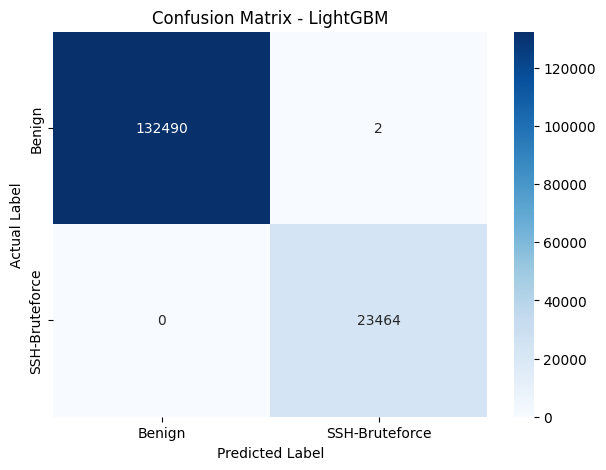

In [47]:
# CONFUSION MATRIX

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 13. Feature Importance

# a.Mengambil nilai feature importance dari model LightGBM


In [48]:
importance = model_lgbm.feature_importances_


In [49]:
# Membuat DataFrame untuk menyimpan
# nama fitur dan nilai importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})


In [50]:
# Mengurutkan fitur dari yang paling penting
# ke yang paling rendah
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# b.Menampilkan 20 Fitur Terpenting

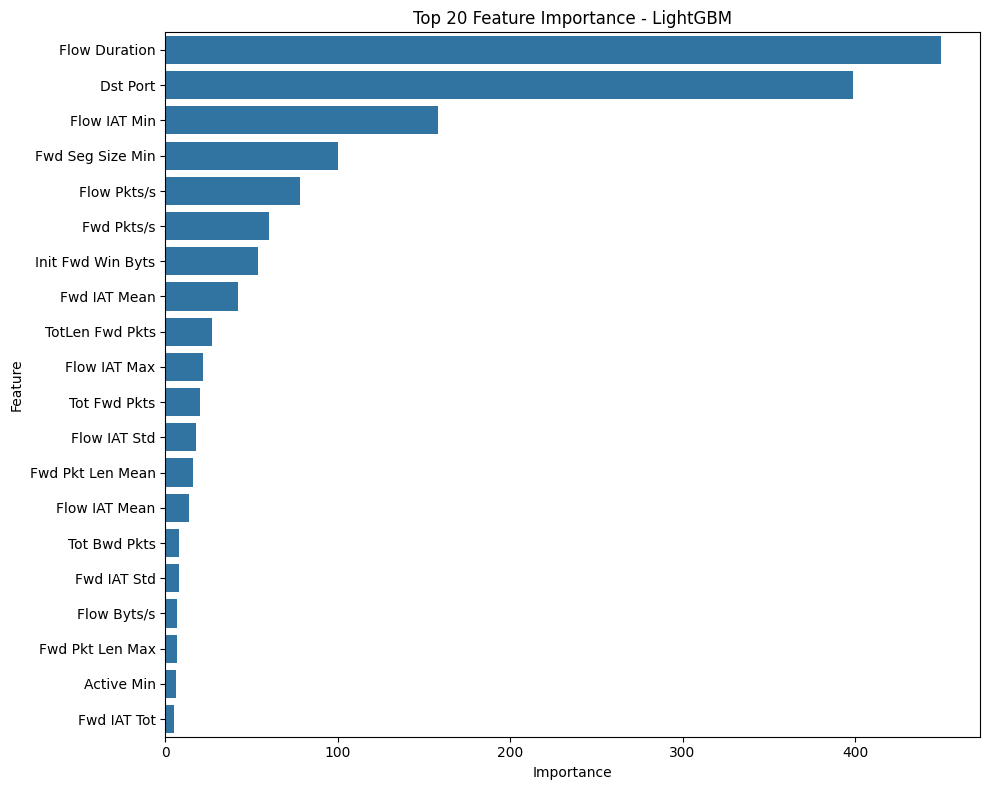

In [51]:
# Menampilkan 20 fitur paling penting
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 14. Feature Selection

# a.Menentukan jumlah fitur yang ingin digunakan

In [52]:
# Kita memilih 20 fitur dengan importance tertinggi
jumlah_fitur = 20

In [53]:
# Mengambil 20 fitur dengan importance tertinggi
selected_features = (
    feature_importance
    .head(jumlah_fitur)["Feature"]
    .tolist()
)


In [54]:
# Menampilkan fitur yang terpilih
print("Fitur yang dipilih:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")


Fitur yang dipilih:
1. Flow Duration
2. Dst Port
3. Flow IAT Min
4. Fwd Seg Size Min
5. Flow Pkts/s
6. Fwd Pkts/s
7. Init Fwd Win Byts
8. Fwd IAT Mean
9. TotLen Fwd Pkts
10. Flow IAT Max
11. Tot Fwd Pkts
12. Flow IAT Std
13. Fwd Pkt Len Mean
14. Flow IAT Mean
15. Tot Bwd Pkts
16. Fwd IAT Std
17. Flow Byts/s
18. Fwd Pkt Len Max
19. Active Min
20. Fwd IAT Tot


# b.Membuat X baru hanya dengan fitur terpilih

In [55]:
X_selected = X[selected_features]


In [56]:
# Melihat ukuran dataset setelah feature selection
print("\nUkuran X sebelum feature selection:")
print(X.shape)

print("\nUkuran X setelah feature selection:")
print(X_selected.shape)


Ukuran X sebelum feature selection:
(779780, 78)

Ukuran X setelah feature selection:
(779780, 20)


# c.Membagi Dataset Dengan Fitur Terpilih

In [57]:
# Membagi dataset berdasarkan fitur yang sudah dipilih
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [58]:
# Menampilkan ukuran data
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected :", X_test_selected.shape)

X_train_selected: (623824, 20)
X_test_selected : (155956, 20)


# d.SMOTE pada Fitur Terpilih

In [59]:
# Membuat objek SMOTE
smote_selected = SMOTE(random_state=42)


# SMOTE hanya pada data training
X_train_selected_smote, y_train_selected_smote = (
    smote_selected.fit_resample(
        X_train_selected,
        y_train_selected
    )
)


In [60]:
# Melihat ukuran setelah SMOTE
print("X_train sebelum SMOTE:", X_train_selected.shape)
print("X_train setelah SMOTE:", X_train_selected_smote.shape)

print("\ny_train sebelum SMOTE:", y_train_selected.shape)
print("y_train setelah SMOTE:", y_train_selected_smote.shape)

X_train sebelum SMOTE: (623824, 20)
X_train setelah SMOTE: (1059932, 20)

y_train sebelum SMOTE: (623824,)
y_train setelah SMOTE: (1059932,)


## 15. Training Ulang LightGBM

# a. Membuat Model LightGBM baru

In [61]:
# Membuat model LightGBM baru
model_lgbm_selected = LGBMClassifier(
    objective="binary",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [62]:
# Melatih model menggunakan 20 fitur terpilih
model_lgbm_selected.fit(
    X_train_selected_smote,
    y_train_selected_smote
)


# Menampilkan informasi
print("Training LightGBM dengan 20 fitur selesai.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

## 16. Prediksi dan Evaluasi Model 20 Fitur

# a.Melakukan Prediksi

In [63]:
# Melakukan prediksi pada data testing
y_pred_selected = model_lgbm_selected.predict(X_test_selected)

# Menampilkan beberapa hasil prediksi
print("20 hasil prediksi pertama:")
print(y_pred_selected[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_selected[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


# b.Evaluasi 20 Fitur


In [64]:
# Menghitung metrik evaluasi
accuracy_selected = accuracy_score(
    y_test_selected,
    y_pred_selected
)

precision_selected = precision_score(
    y_test_selected,
    y_pred_selected
)

recall_selected = recall_score(
    y_test_selected,
    y_pred_selected
)

f1_selected = f1_score(
    y_test_selected,
    y_pred_selected
)


# Menampilkan hasil evaluasi
print("Hasil Evaluasi Model LightGBM - 20 Fitur")
print("------------------------------------------")
print(f"Accuracy  : {accuracy_selected:.4f}")
print(f"Precision : {precision_selected:.4f}")
print(f"Recall    : {recall_selected:.4f}")
print(f"F1-Score  : {f1_selected:.4f}")

Hasil Evaluasi Model LightGBM - 20 Fitur
------------------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000


# c. Confusion Matrix 20 Fitur

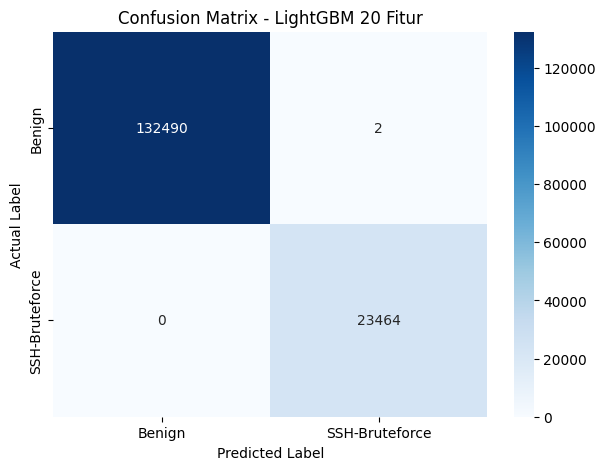

In [65]:
# Membuat confusion matrix
cm_selected = confusion_matrix(
    y_test_selected,
    y_pred_selected
)


# Membuat visualisasi
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_selected,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM 20 Fitur")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# d. Membandingkan Training dan Testing

In [66]:
# Prediksi pada data training
y_train_pred_selected = model_lgbm_selected.predict(
    X_train_selected
)

# Prediksi pada data testing
y_test_pred_selected = model_lgbm_selected.predict(
    X_test_selected
)

# Menghitung accuracy training
accuracy_train_selected = accuracy_score(
    y_train_selected,
    y_train_pred_selected
)

# Menghitung accuracy testing
accuracy_test_selected = accuracy_score(
    y_test_selected,
    y_test_pred_selected
)

print("Perbandingan Training dan Testing")
print("----------------------------------")
print(f"Training Accuracy : {accuracy_train_selected:.4f}")
print(f"Testing Accuracy  : {accuracy_test_selected:.4f}")

# Menghitung selisih accuracy
selisih_accuracy = (
    accuracy_train_selected -
    accuracy_test_selected
)

print(f"Selisih Accuracy   : {selisih_accuracy:.4f}")

Perbandingan Training dan Testing
----------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 1.0000
Selisih Accuracy   : 0.0000


## 17. Hyperparameter Tuning LightGBM

# a.Menentukan parameter yang akan diuji

In [67]:
from sklearn.model_selection import GridSearchCV

lgbm_tuning = LGBMClassifier(
    objective="binary",
    random_state=42
)

# Parameter yang akan diuji
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6],
    "num_leaves": [15, 31]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=1
)

# Training tuning
grid_search.fit(
    X_train_selected_smote,
    y_train_selected_smote
)

print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nF1-Score terbaik:")
print(grid_search.best_score_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## 18. Training Model dengan Parameter Terbaik

# a.Training Model dengan Parameter Terbaik


In [68]:
model_lgbm_final = LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    num_leaves=15,
    random_state=42
)

# Training menggunakan data training yang sudah SMOTE
model_lgbm_final.fit(
    X_train_selected_smote,
    y_train_selected_smote
)

print("Training model dengan parameter terbaik selesai.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [69]:
# Melakukan prediksi pada data testing
y_pred_final = model_lgbm_final.predict(
    X_test_selected
)

print("20 hasil prediksi pertama:")
print(y_pred_final[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_selected[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


In [70]:
accuracy_final = accuracy_score(
    y_test_selected,
    y_pred_final
)

precision_final = precision_score(
    y_test_selected,
    y_pred_final
)

recall_final = recall_score(
    y_test_selected,
    y_pred_final
)

f1_final = f1_score(
    y_test_selected,
    y_pred_final
)

print("Hasil Evaluasi Model Final LightGBM")
print("------------------------------------")
print(f"Accuracy  : {accuracy_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1-Score  : {f1_final:.4f}")

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_selected,
        y_pred_final,
        target_names=label_encoder.classes_
    )
)

Hasil Evaluasi Model Final LightGBM
------------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



# b.Confusion Matrix

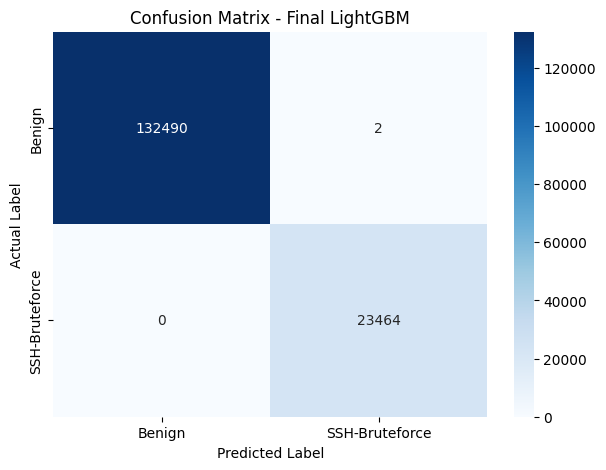

In [71]:


cm_final = confusion_matrix(
    y_test_selected,
    y_pred_final
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


# c.Feature Importance Final

In [72]:
# Mengambil nilai feature importance
importance_final = model_lgbm_final.feature_importances_

# Membuat dataframe feature importance
feature_importance_final = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": importance_final
})

# Mengurutkan dari fitur paling penting
feature_importance_final = feature_importance_final.sort_values(
    by="Importance",
    ascending=False
)

# Menampilkan seluruh 20 fitur
print("Feature Importance Model Final:")
print(feature_importance_final)

Feature Importance Model Final:
              Feature  Importance
0       Flow Duration         545
1            Dst Port         467
2        Flow IAT Min         245
3    Fwd Seg Size Min         200
6   Init Fwd Win Byts         134
5          Fwd Pkts/s          88
4         Flow Pkts/s          50
11       Flow IAT Std          29
9        Flow IAT Max          16
8     TotLen Fwd Pkts          13
10       Tot Fwd Pkts           9
7        Fwd IAT Mean           5
18         Active Min           5
12   Fwd Pkt Len Mean           4
13      Flow IAT Mean           4
14       Tot Bwd Pkts           3
19        Fwd IAT Tot           3
16        Flow Byts/s           2
15        Fwd IAT Std           1
17    Fwd Pkt Len Max           0


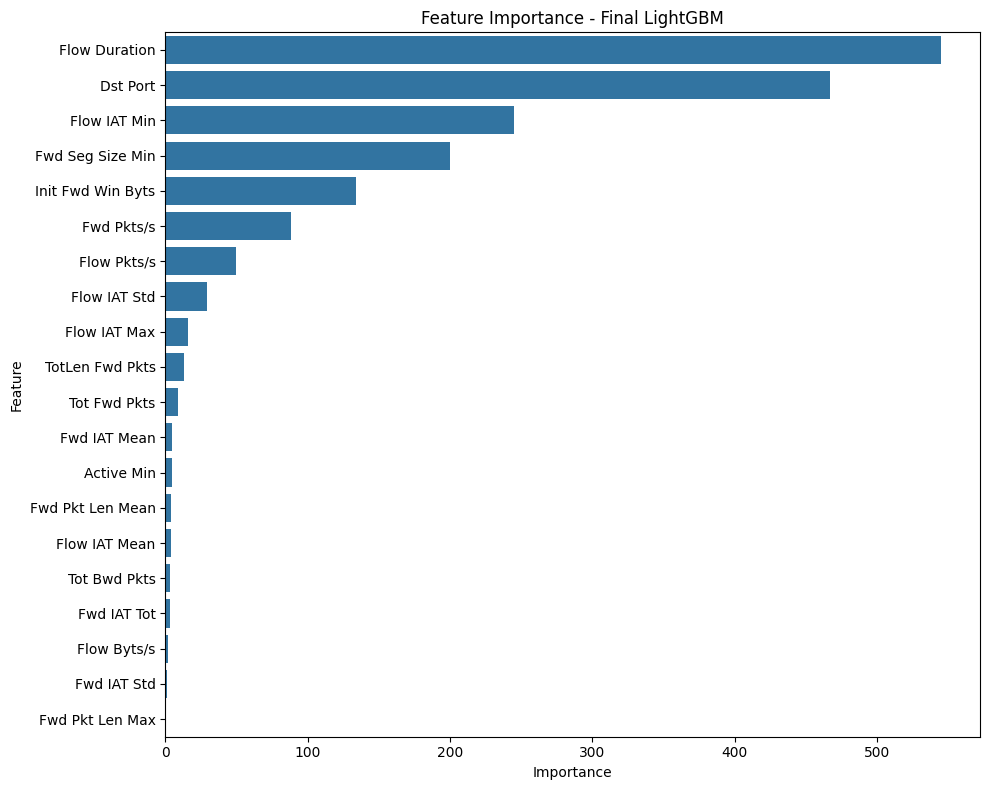

In [73]:
# VISUALISASI FEATURE IMPORTANCE

top_features_final = feature_importance_final.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features_final,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Final LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 19. Melakukan Pelatihan ulang dengan 12 Fitur Importance

# a.Melihat 12 fitur importance

In [74]:
jumlah_fitur = 12

# Mengambil 12 fitur dengan importance tertinggi
selected_features_12 = (
    feature_importance_final
    .head(jumlah_fitur)["Feature"]
    .tolist()
)

print("12 Fitur Terpilih:")
print("--------------------------------")

for i, feature in enumerate(selected_features_12, start=1):
    print(f"{i}. {feature}")

print("\nJumlah fitur:", len(selected_features_12))

12 Fitur Terpilih:
--------------------------------
1. Flow Duration
2. Dst Port
3. Flow IAT Min
4. Fwd Seg Size Min
5. Init Fwd Win Byts
6. Fwd Pkts/s
7. Flow Pkts/s
8. Flow IAT Std
9. Flow IAT Max
10. TotLen Fwd Pkts
11. Tot Fwd Pkts
12. Fwd IAT Mean

Jumlah fitur: 12


# b.Membuat Dataset dengan 12 Fitur

In [75]:
# Mengambil hanya 12 fitur yang sudah dipilih
X_selected_12 = X[selected_features_12]

print("Ukuran X sebelum feature selection:")
print(X.shape)

print("\nUkuran X setelah menggunakan 12 fitur:")
print(X_selected_12.shape)

print("\nNama 12 fitur:")
print(X_selected_12.columns.tolist())

Ukuran X sebelum feature selection:
(779780, 78)

Ukuran X setelah menggunakan 12 fitur:
(779780, 12)

Nama 12 fitur:
['Flow Duration', 'Dst Port', 'Flow IAT Min', 'Fwd Seg Size Min', 'Init Fwd Win Byts', 'Fwd Pkts/s', 'Flow Pkts/s', 'Flow IAT Std', 'Flow IAT Max', 'TotLen Fwd Pkts', 'Tot Fwd Pkts', 'Fwd IAT Mean']


# c.Train Split Test 12 fitur

In [76]:
X_train_12, X_test_12, y_train_12, y_test_12 = train_test_split(
    X_selected_12,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Menampilkan ukuran masing-masing data
print("Ukuran data:")
print("--------------------------------")
print("X_train_12:", X_train_12.shape)
print("X_test_12 :", X_test_12.shape)
print("y_train_12:", y_train_12.shape)
print("y_test_12 :", y_test_12.shape)

# Menampilkan distribusi label training
print("\nDistribusi label Training:")
print(pd.Series(y_train_12).value_counts())

# Menampilkan distribusi label testing
print("\nDistribusi label Testing:")
print(pd.Series(y_test_12).value_counts())

Ukuran data:
--------------------------------
X_train_12: (623824, 12)
X_test_12 : (155956, 12)
y_train_12: (623824,)
y_test_12 : (155956,)

Distribusi label Training:
0    529966
1     93858
Name: count, dtype: int64

Distribusi label Testing:
0    132492
1     23464
Name: count, dtype: int64


# d.Membagi Training menjadi Training dan Validation

In [77]:
X_train_12_final, X_val_12, y_train_12_final, y_val_12 = train_test_split(
    X_train_12,
    y_train_12,
    test_size=0.20,
    random_state=42,
    stratify=y_train_12
)

print("Ukuran data:")
print("--------------------------------")
print("X_train_12_final :", X_train_12_final.shape)
print("X_val_12        :", X_val_12.shape)
print("X_test_12       :", X_test_12.shape)

print("\ny_train_12_final :", y_train_12_final.shape)
print("y_val_12        :", y_val_12.shape)
print("y_test_12       :", y_test_12.shape)

print("\nDistribusi label Training:")
print(pd.Series(y_train_12_final).value_counts())

print("\nDistribusi label Validation:")
print(pd.Series(y_val_12).value_counts())

print("\nDistribusi label Testing:")
print(pd.Series(y_test_12).value_counts())

Ukuran data:
--------------------------------
X_train_12_final : (499059, 12)
X_val_12        : (124765, 12)
X_test_12       : (155956, 12)

y_train_12_final : (499059,)
y_val_12        : (124765,)
y_test_12       : (155956,)

Distribusi label Training:
0    423973
1     75086
Name: count, dtype: int64

Distribusi label Validation:
0    105993
1     18772
Name: count, dtype: int64

Distribusi label Testing:
0    132492
1     23464
Name: count, dtype: int64


# e.SMOTE Pada Data Training

Distribusi label sebelum SMOTE:
0    423973
1     75086
Name: count, dtype: int64

Distribusi label setelah SMOTE:
0    423973
1    423973
Name: count, dtype: int64

Ukuran data:
--------------------------------
Training sebelum SMOTE : (499059, 12)
Training setelah SMOTE : (847946, 12)
Validation             : (124765, 12)
Testing                : (155956, 12)


/tmp/ipykernel_1164/1767987108.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1164/1767987108.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


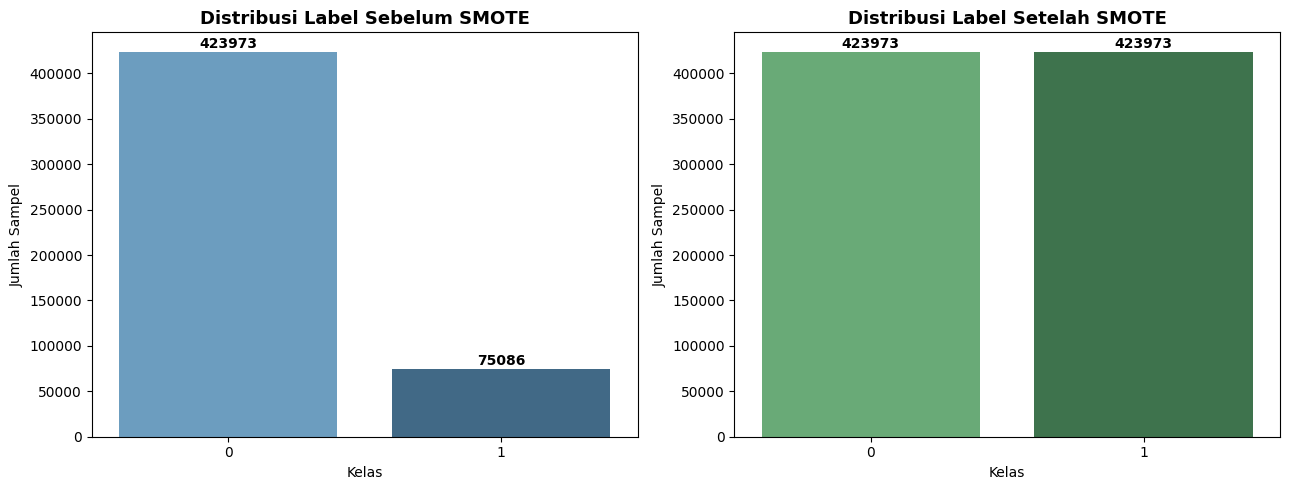

/tmp/ipykernel_1164/1767987108.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


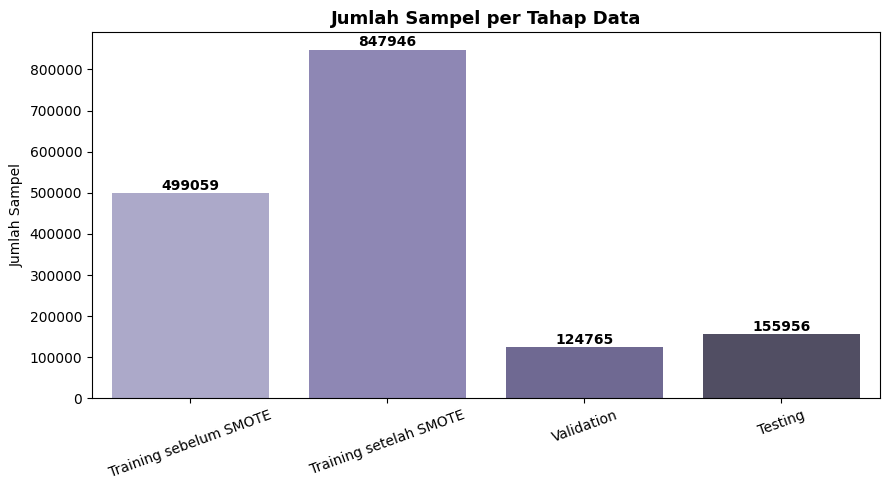

In [78]:
# Membuat objek SMOTE
smote_12_final = SMOTE(random_state=42)

# SMOTE hanya diterapkan pada data training
X_train_12_final_smote, y_train_12_final_smote = (
    smote_12_final.fit_resample(
        X_train_12_final,
        y_train_12_final
    )
)

# Menyimpan distribusi label sebelum dan setelah SMOTE
dist_before = pd.Series(y_train_12_final).value_counts().sort_index()
dist_after  = pd.Series(y_train_12_final_smote).value_counts().sort_index()

# Menampilkan distribusi sebelum SMOTE
print("Distribusi label sebelum SMOTE:")
print(dist_before)

# Menampilkan distribusi setelah SMOTE
print("\nDistribusi label setelah SMOTE:")
print(dist_after)

# Menampilkan ukuran data
print("\nUkuran data:")
print("--------------------------------")
print("Training sebelum SMOTE :", X_train_12_final.shape)
print("Training setelah SMOTE :", X_train_12_final_smote.shape)
print("Validation             :", X_val_12.shape)
print("Testing                :", X_test_12.shape)

# VISUALISASI DISTRIBUSI LABEL
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart distribusi label sebelum SMOTE
sns.barplot(
    x=dist_before.index.astype(str),
    y=dist_before.values,
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Distribusi Label Sebelum SMOTE",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")
for i, v in enumerate(dist_before.values):
    axes[0].text(i, v + max(dist_before.values) * 0.01, str(v),
                 ha="center", fontweight="bold")

# Bar chart distribusi label setelah SMOTE
sns.barplot(
    x=dist_after.index.astype(str),
    y=dist_after.values,
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("Distribusi Label Setelah SMOTE",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Sampel")
for i, v in enumerate(dist_after.values):
    axes[1].text(i, v + max(dist_after.values) * 0.01, str(v),
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Menyusun data ukuran untuk visualisasi
ukuran_data = pd.DataFrame({
    "Tahap": [
        "Training sebelum SMOTE",
        "Training setelah SMOTE",
        "Validation",
        "Testing"
    ],
    "Jumlah Sampel": [
        X_train_12_final.shape[0],
        X_train_12_final_smote.shape[0],
        X_val_12.shape[0],
        X_test_12.shape[0]
    ]
})

# Bar chart jumlah sampel per tahap data
plt.figure(figsize=(9, 5))
sns.barplot(
    x="Tahap",
    y="Jumlah Sampel",
    data=ukuran_data,
    palette="Purples_d"
)
plt.title("Jumlah Sampel per Tahap Data",
          fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=20)
for i, v in enumerate(ukuran_data["Jumlah Sampel"]):
    plt.text(i, v + max(ukuran_data["Jumlah Sampel"]) * 0.01, str(v),
             ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# f.Membuat model LIGHTBGM 12 Fitur

In [79]:
model_lgbm_12_final = LGBMClassifier(
    objective="binary",

    # Mengontrol kompleksitas pohon
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=7,
    min_child_samples=100,

    # Regularisasi
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    # Subsampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # Agar hasil dapat direproduksi
    random_state=42
)

print("Model LightGBM 12 fitur berhasil dibuat.")

Model LightGBM 12 fitur berhasil dibuat.


# g.Training LIGHTGBM 12 fitur dengan early stopping

In [80]:
import lightgbm as lgb

model_lgbm_12_final.fit(
    X_train_12_final_smote,
    y_train_12_final_smote,

    # Data validation untuk memantau performa
    eval_set=[
        (X_val_12, y_val_12)
    ],

    # Metrik yang dipantau
    eval_metric="binary_logloss",

    # Berhenti jika validation tidak membaik
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

print("\nTraining LightGBM selesai.")
print("Best iteration:", model_lgbm_12_final.best_iteration_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 423973, number of negative: 423973
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2756
[LightGBM] [Info] Number of data points in the train set: 847946, number of used features: 12
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

# h. Prediksi model 12 Fitur

In [81]:
y_pred_12 = model_lgbm_12_final.predict(
    X_test_12
)

print("20 hasil prediksi pertama:")
print(y_pred_12[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_12[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


# i. Hasil dan Evaluasi

In [82]:
accuracy_12 = accuracy_score(
    y_test_12,
    y_pred_12
)

precision_12 = precision_score(
    y_test_12,
    y_pred_12
)

recall_12 = recall_score(
    y_test_12,
    y_pred_12
)

f1_12 = f1_score(
    y_test_12,
    y_pred_12
)

print("Hasil Evaluasi Model LightGBM - 12 Fitur")
print("------------------------------------------")
print(f"Accuracy  : {accuracy_12:.4f}")
print(f"Precision : {precision_12:.4f}")
print(f"Recall    : {recall_12:.4f}")
print(f"F1-Score  : {f1_12:.4f}")

Hasil Evaluasi Model LightGBM - 12 Fitur
------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


# j.Classificatin Report

In [83]:
print("\nClassification Report:")
print(
    classification_report(
        y_test_12,
        y_pred_12,
        target_names=label_encoder.classes_
    )
)


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



# k.Membandingkan Training, Validation, dan *Testing*

In [84]:
# Prediksi pada data training
y_train_pred_12 = model_lgbm_12_final.predict(
    X_train_12_final
)

# Prediksi pada data validation
y_val_pred_12 = model_lgbm_12_final.predict(
    X_val_12
)

# Prediksi pada data testing
y_test_pred_12 = model_lgbm_12_final.predict(
    X_test_12
)

# Menghitung accuracy
accuracy_train_12 = accuracy_score(
    y_train_12_final,
    y_train_pred_12
)

accuracy_val_12 = accuracy_score(
    y_val_12,
    y_val_pred_12
)

accuracy_test_12 = accuracy_score(
    y_test_12,
    y_test_pred_12
)

print("Perbandingan Accuracy")
print("--------------------------------")
print(f"Training   : {accuracy_train_12:.4f}")
print(f"Validation : {accuracy_val_12:.4f}")
print(f"Testing    : {accuracy_test_12:.4f}")

Perbandingan Accuracy
--------------------------------
Training   : 1.0000
Validation : 1.0000
Testing    : 1.0000


# l. Feature Importance 12 fitur

Feature Importance Model 12 Fitur
-----------------------------------
              Feature  Importance
1            Dst Port         334
4   Init Fwd Win Byts         314
3    Fwd Seg Size Min         211
5          Fwd Pkts/s         192
2        Flow IAT Min         127
9     TotLen Fwd Pkts          95
6         Flow Pkts/s          91
0       Flow Duration          72
10       Tot Fwd Pkts           7
7        Flow IAT Std           6
8        Flow IAT Max           4
11       Fwd IAT Mean           2


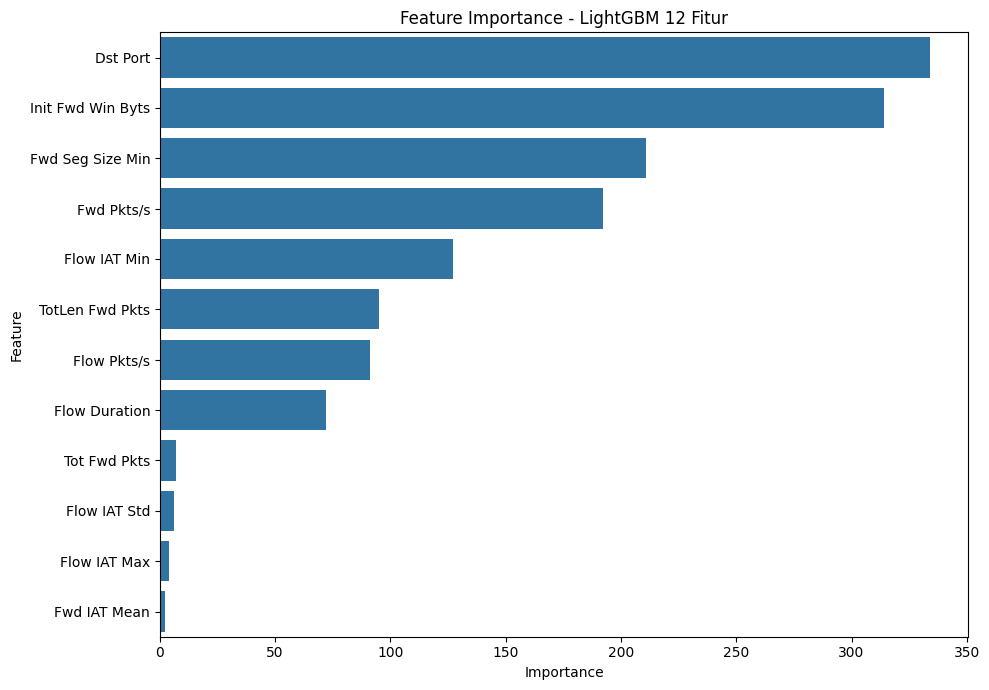

In [85]:
# ============================================
# 26. FEATURE IMPORTANCE - MODEL 12 FITUR
# ============================================

# Mengambil nilai feature importance dari model
importance_12 = model_lgbm_12_final.feature_importances_

# Membuat DataFrame feature importance
feature_importance_12 = pd.DataFrame({
    "Feature": X_train_12_final.columns,
    "Importance": importance_12
})

# Mengurutkan dari importance tertinggi
feature_importance_12 = feature_importance_12.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance Model 12 Fitur")
print("-----------------------------------")
print(feature_importance_12)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_12,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - LightGBM 12 Fitur")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 20. Melakukan Pelatihan ulang dengan 10 Fitur Importance

# a. Feature Selection 10 fitur

In [86]:
selected_features_10 = [
    "Flow Pkts/s",
    "Init Fwd Win Byts",
    "Flow IAT Min",
    "Flow Duration",
    "Flow IAT Mean",
    "Init Bwd Win Byts",
    "Bwd Header Len",
    "Flow IAT Std",
    "Bwd Pkt Len Mean",
    "Tot Fwd Pkts"
]

print("10 Fitur yang digunakan:")
print("--------------------------------")

for i, feature in enumerate(selected_features_10, start=1):
    print(f"{i}. {feature}")

print("\nJumlah fitur:", len(selected_features_10))

10 Fitur yang digunakan:
--------------------------------
1. Flow Pkts/s
2. Init Fwd Win Byts
3. Flow IAT Min
4. Flow Duration
5. Flow IAT Mean
6. Init Bwd Win Byts
7. Bwd Header Len
8. Flow IAT Std
9. Bwd Pkt Len Mean
10. Tot Fwd Pkts

Jumlah fitur: 10


# b.Buat dataset

In [87]:
# Membuat dataset dengan 10 fitur
X_selected_10 = X[selected_features_10]

print("\nUkuran dataset:")
print(X_selected_10.shape)


Ukuran dataset:
(779780, 10)


# c.Train Split Tes 10 Fitur

In [88]:
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(
    X_selected_10,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Menampilkan ukuran data
print("Ukuran data:")
print("--------------------------------")
print("X_train_10:", X_train_10.shape)
print("X_test_10 :", X_test_10.shape)
print("y_train_10:", y_train_10.shape)
print("y_test_10 :", y_test_10.shape)

# Distribusi label
print("\nDistribusi label Training:")
print(pd.Series(y_train_10).value_counts())

print("\nDistribusi label Testing:")
print(pd.Series(y_test_10).value_counts())

Ukuran data:
--------------------------------
X_train_10: (623824, 10)
X_test_10 : (155956, 10)
y_train_10: (623824,)
y_test_10 : (155956,)

Distribusi label Training:
0    529966
1     93858
Name: count, dtype: int64

Distribusi label Testing:
0    132492
1     23464
Name: count, dtype: int64


d.Membagi Training menjadi Training dan Validation 10 Fitur

In [89]:
X_train_10_final, X_val_10, y_train_10_final, y_val_10 = train_test_split(
    X_train_10,
    y_train_10,
    test_size=0.20,
    random_state=42,
    stratify=y_train_10
)

# Menampilkan ukuran data
print("Ukuran data:")
print("--------------------------------")
print("X_train_10_final :", X_train_10_final.shape)
print("X_val_10         :", X_val_10.shape)
print("X_test_10        :", X_test_10.shape)

print("\ny_train_10_final :", y_train_10_final.shape)
print("y_val_10         :", y_val_10.shape)
print("y_test_10        :", y_test_10.shape)

# Menampilkan distribusi label
print("\nDistribusi label Training:")
print(pd.Series(y_train_10_final).value_counts())

print("\nDistribusi label Validation:")
print(pd.Series(y_val_10).value_counts())

print("\nDistribusi label Testing:")
print(pd.Series(y_test_10).value_counts())

Ukuran data:
--------------------------------
X_train_10_final : (499059, 10)
X_val_10         : (124765, 10)
X_test_10        : (155956, 10)

y_train_10_final : (499059,)
y_val_10         : (124765,)
y_test_10        : (155956,)

Distribusi label Training:
0    423973
1     75086
Name: count, dtype: int64

Distribusi label Validation:
0    105993
1     18772
Name: count, dtype: int64

Distribusi label Testing:
0    132492
1     23464
Name: count, dtype: int64


# e. SMOTE 10 fitur

In [90]:
# Membuat objek SMOTE
smote_10 = SMOTE(random_state=42)

# SMOTE hanya pada data training
X_train_10_final_smote, y_train_10_final_smote = (
    smote_10.fit_resample(
        X_train_10_final,
        y_train_10_final
    )
)

# Distribusi sebelum SMOTE
print("Distribusi label sebelum SMOTE:")
print(pd.Series(y_train_10_final).value_counts())

# Distribusi setelah SMOTE
print("\nDistribusi label setelah SMOTE:")
print(pd.Series(y_train_10_final_smote).value_counts())

# Ukuran data
print("\nUkuran data:")
print("--------------------------------")
print("Training sebelum SMOTE :", X_train_10_final.shape)
print("Training setelah SMOTE :", X_train_10_final_smote.shape)
print("Validation             :", X_val_10.shape)
print("Testing                :", X_test_10.shape)

Distribusi label sebelum SMOTE:
0    423973
1     75086
Name: count, dtype: int64

Distribusi label setelah SMOTE:
0    423973
1    423973
Name: count, dtype: int64

Ukuran data:
--------------------------------
Training sebelum SMOTE : (499059, 10)
Training setelah SMOTE : (847946, 10)
Validation             : (124765, 10)
Testing                : (155956, 10)


# f.Membuat model LIGHTGBM 10 fitur

In [91]:
model_lgbm_10_final = LGBMClassifier(
    objective="binary",

    # Mengontrol kompleksitas pohon
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=7,
    min_child_samples=100,

    # Regularisasi
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    # Subsampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # Reproducibility
    random_state=42
)

print("Model LightGBM 10 fitur berhasil dibuat.")

Model LightGBM 10 fitur berhasil dibuat.


# g.Training LIGHTGBM 10 fitur

In [92]:
model_lgbm_10_final.fit(
    X_train_10_final_smote,
    y_train_10_final_smote,

    # Data validation
    eval_set=[
        (X_val_10, y_val_10)
    ],

    # Metrik yang dipantau
    eval_metric="binary_logloss",

    # Early stopping
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

print("\nTraining LightGBM 10 fitur selesai.")
print("Best iteration:", model_lgbm_10_final.best_iteration_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 423973, number of negative: 423973
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2438
[LightGBM] [Info] Number of data points in the train set: 847946, number of used features: 10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

# h.Prediksi model 10 fitur

In [93]:
y_pred_10 = model_lgbm_10_final.predict(
    X_test_10
)

print("20 hasil prediksi pertama:")
print(y_pred_10[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_10[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


# i.Evaluasi Model LIGHTGBM 10 fitur

In [94]:
accuracy_10 = accuracy_score(
    y_test_10,
    y_pred_10
)

precision_10 = precision_score(
    y_test_10,
    y_pred_10
)

recall_10 = recall_score(
    y_test_10,
    y_pred_10
)

f1_10 = f1_score(
    y_test_10,
    y_pred_10
)

print("Hasil Evaluasi Model LightGBM - 10 Fitur")
print("------------------------------------------")
print(f"Accuracy  : {accuracy_10:.4f}")
print(f"Precision : {precision_10:.4f}")
print(f"Recall    : {recall_10:.4f}")
print(f"F1-Score  : {f1_10:.4f}")

Hasil Evaluasi Model LightGBM - 10 Fitur
------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [95]:
print("\nClassification Report:")
print(
    classification_report(
        y_test_10,
        y_pred_10,
        target_names=label_encoder.classes_
    )
)


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



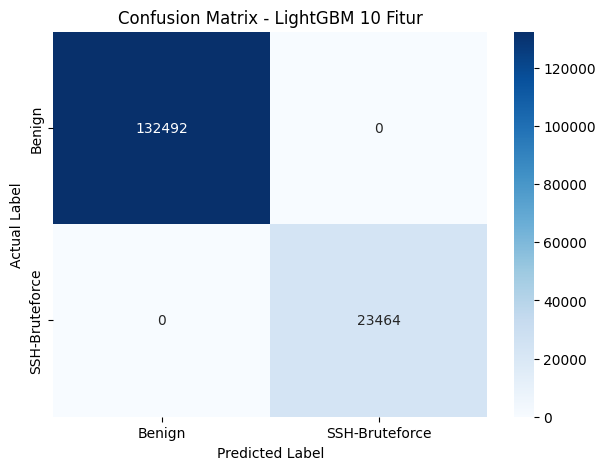

In [96]:
cm_10 = confusion_matrix(
    y_test_10,
    y_pred_10
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_10,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM 10 Fitur")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# j.Membandingkan Training, Vlidation, dan Testing

In [97]:
# Prediksi data training
y_train_pred_10 = model_lgbm_10_final.predict(
    X_train_10_final
)

# Prediksi data validation
y_val_pred_10 = model_lgbm_10_final.predict(
    X_val_10
)

# Prediksi data testing
y_test_pred_10 = model_lgbm_10_final.predict(
    X_test_10
)

# Menghitung accuracy
accuracy_train_10 = accuracy_score(
    y_train_10_final,
    y_train_pred_10
)

accuracy_val_10 = accuracy_score(
    y_val_10,
    y_val_pred_10
)

accuracy_test_10 = accuracy_score(
    y_test_10,
    y_test_pred_10
)

print("Perbandingan Accuracy - 10 Fitur")
print("----------------------------------")
print(f"Training   : {accuracy_train_10:.4f}")
print(f"Validation : {accuracy_val_10:.4f}")
print(f"Testing    : {accuracy_test_10:.4f}")

Perbandingan Accuracy - 10 Fitur
----------------------------------
Training   : 1.0000
Validation : 1.0000
Testing    : 1.0000


# k.Feature Importance 10 fitur

In [98]:
# ============================================
# 36. FEATURE IMPORTANCE - MODEL 10 FITUR
# ============================================

# Mengambil nilai feature importance
importance_10 = model_lgbm_10_final.feature_importances_

# Membuat DataFrame
feature_importance_10 = pd.DataFrame({
    "Feature": X_train_10_final.columns,
    "Importance": importance_10
})

# Mengurutkan berdasarkan importance tertinggi
feature_importance_10 = feature_importance_10.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance Model 10 Fitur")
print("-----------------------------------")
print(feature_importance_10)

Feature Importance Model 10 Fitur
-----------------------------------
             Feature  Importance
1  Init Fwd Win Byts        1185
5  Init Bwd Win Byts         571
6     Bwd Header Len         458
8   Bwd Pkt Len Mean         406
0        Flow Pkts/s         358
2       Flow IAT Min         339
3      Flow Duration         262
4      Flow IAT Mean         256
9       Tot Fwd Pkts         159
7       Flow IAT Std          11


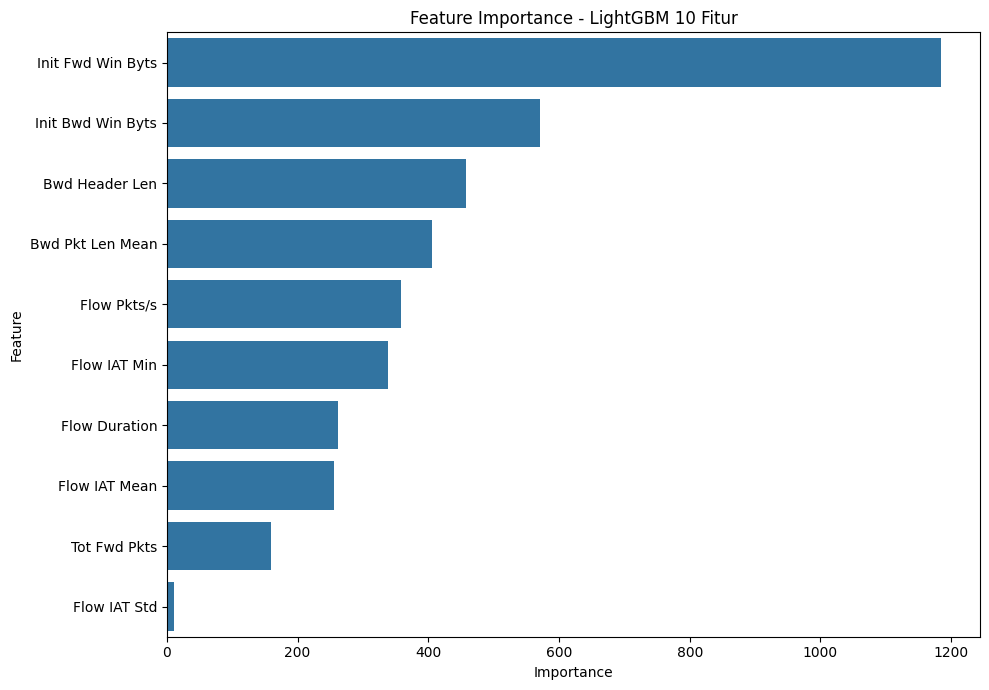

In [99]:
# ============================================
# VISUALISASI FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_10,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - LightGBM 10 Fitur")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 21. Melatih model dengan data temporal

# a.Menyiapkan data temporal

In [100]:
# Membuat salinan data
df_temporal_10 = df_model.copy()

# Mengubah Timestamp menjadi datetime
df_temporal_10["Timestamp"] = pd.to_datetime(
    df_temporal_10["Timestamp"],
    errors="coerce",
    format="mixed"
)

# Menghapus Timestamp yang tidak terbaca
df_temporal_10 = df_temporal_10.dropna(
    subset=["Timestamp"]
)

# Mengambil data pada periode SSH-Bruteforce
start_time = pd.Timestamp("2018-02-14 02:01:21")
end_time = pd.Timestamp("2018-02-14 03:32:30")

df_temporal_10 = df_temporal_10[
    (df_temporal_10["Timestamp"] >= start_time) &
    (df_temporal_10["Timestamp"] <= end_time)
].copy()

# Mengurutkan berdasarkan waktu
df_temporal_10 = df_temporal_10.sort_values(
    by="Timestamp"
).reset_index(drop=True)

# Menampilkan informasi
print("Ukuran data temporal:")
print(df_temporal_10.shape)

print("\nRentang waktu:")
print("Mulai  :", df_temporal_10["Timestamp"].min())
print("Selesai:", df_temporal_10["Timestamp"].max())

print("\nDistribusi label:")
print(df_temporal_10["Label"].value_counts())

print("\nPersentase label:")
print(
    df_temporal_10["Label"]
    .value_counts(normalize=True) * 100
)

Ukuran data temporal:
(188970, 80)

Rentang waktu:
Mulai  : 2018-02-14 02:01:21
Selesai: 2018-02-14 03:32:30

Distribusi label:
Label
SSH-Bruteforce    117322
Benign             71648
Name: count, dtype: int64

Persentase label:
Label
SSH-Bruteforce    62.084987
Benign            37.915013
Name: proportion, dtype: float64


# b.Temporal Train test split 10 fitur


In [101]:
# Pastikan data sudah diurutkan berdasarkan waktu
df_temporal_10 = df_temporal_10.sort_values(
    by="Timestamp"
).reset_index(drop=True)

# Menentukan batas 80% data untuk training
train_size_temporal = int(
    len(df_temporal_10) * 0.80
)

# Membagi data berdasarkan urutan waktu
df_train_temporal_10 = df_temporal_10.iloc[
    :train_size_temporal
].copy()

df_test_temporal_10 = df_temporal_10.iloc[
    train_size_temporal:
].copy()

# Menampilkan ukuran data
print("Ukuran data:")
print("--------------------------------")
print("Training :", df_train_temporal_10.shape)
print("Testing  :", df_test_temporal_10.shape)

# Menampilkan rentang waktu
print("\nRentang waktu Training:")
print("Mulai  :", df_train_temporal_10["Timestamp"].min())
print("Selesai:", df_train_temporal_10["Timestamp"].max())

print("\nRentang waktu Testing:")
print("Mulai  :", df_test_temporal_10["Timestamp"].min())
print("Selesai:", df_test_temporal_10["Timestamp"].max())

# Distribusi label
print("\nDistribusi label Training:")
print(df_train_temporal_10["Label"].value_counts())

print("\nDistribusi label Testing:")
print(df_test_temporal_10["Label"].value_counts())

Ukuran data:
--------------------------------
Training : (151176, 80)
Testing  : (37794, 80)

Rentang waktu Training:
Mulai  : 2018-02-14 02:01:21
Selesai: 2018-02-14 03:13:33

Rentang waktu Testing:
Mulai  : 2018-02-14 03:13:33
Selesai: 2018-02-14 03:32:30

Distribusi label Training:
Label
SSH-Bruteforce    92856
Benign            58320
Name: count, dtype: int64

Distribusi label Testing:
Label
SSH-Bruteforce    24466
Benign            13328
Name: count, dtype: int64


# c.Membentuk x dan y untuk temporal data

In [102]:

# --------------------------------------------
# DATA TRAINING
# --------------------------------------------

X_train_temporal_10 = df_train_temporal_10[
    selected_features_10
]

y_train_temporal_10 = df_train_temporal_10[
    "Label"
]

# --------------------------------------------
# DATA TESTING
# --------------------------------------------

X_test_temporal_10 = df_test_temporal_10[
    selected_features_10
]

y_test_temporal_10 = df_test_temporal_10[
    "Label"
]

# --------------------------------------------
# ENCODING LABEL
# --------------------------------------------

# Menggunakan label_encoder yang sudah dibuat
y_train_temporal_10 = label_encoder.transform(
    y_train_temporal_10
)

y_test_temporal_10 = label_encoder.transform(
    y_test_temporal_10
)

# --------------------------------------------
# CEK UKURAN DATA
# --------------------------------------------

print("Ukuran data:")
print("--------------------------------")
print("X_train_temporal_10 :", X_train_temporal_10.shape)
print("X_test_temporal_10  :", X_test_temporal_10.shape)

print("\ny_train_temporal_10 :", y_train_temporal_10.shape)
print("y_test_temporal_10  :", y_test_temporal_10.shape)

# --------------------------------------------
# CEK DISTRIBUSI LABEL
# --------------------------------------------

print("\nDistribusi label Training:")
print(pd.Series(y_train_temporal_10).value_counts())

print("\nDistribusi label Testing:")
print(pd.Series(y_test_temporal_10).value_counts())

Ukuran data:
--------------------------------
X_train_temporal_10 : (151176, 10)
X_test_temporal_10  : (37794, 10)

y_train_temporal_10 : (151176,)
y_test_temporal_10  : (37794,)

Distribusi label Training:
1    92856
0    58320
Name: count, dtype: int64

Distribusi label Testing:
1    24466
0    13328
Name: count, dtype: int64


# d. Training validation split pada temporal training

In [103]:
X_train_temporal_10_final, X_val_temporal_10, \
y_train_temporal_10_final, y_val_temporal_10 = train_test_split(
    X_train_temporal_10,
    y_train_temporal_10,
    test_size=0.20,
    random_state=42,
    stratify=y_train_temporal_10
)

# Menampilkan ukuran data
print("Ukuran data:")
print("--------------------------------")
print(
    "X_train_temporal_10_final :",
    X_train_temporal_10_final.shape
)

print(
    "X_val_temporal_10         :",
    X_val_temporal_10.shape
)

print(
    "X_test_temporal_10        :",
    X_test_temporal_10.shape
)

print(
    "\ny_train_temporal_10_final :",
    y_train_temporal_10_final.shape
)

print(
    "y_val_temporal_10         :",
    y_val_temporal_10.shape
)

print(
    "y_test_temporal_10        :",
    y_test_temporal_10.shape
)

# Distribusi label
print("\nDistribusi label Training:")
print(
    pd.Series(y_train_temporal_10_final)
    .value_counts()
)

print("\nDistribusi label Validation:")
print(
    pd.Series(y_val_temporal_10)
    .value_counts()
)

print("\nDistribusi label Testing:")
print(
    pd.Series(y_test_temporal_10)
    .value_counts()
)

Ukuran data:
--------------------------------
X_train_temporal_10_final : (120940, 10)
X_val_temporal_10         : (30236, 10)
X_test_temporal_10        : (37794, 10)

y_train_temporal_10_final : (120940,)
y_val_temporal_10         : (30236,)
y_test_temporal_10        : (37794,)

Distribusi label Training:
1    74284
0    46656
Name: count, dtype: int64

Distribusi label Validation:
1    18572
0    11664
Name: count, dtype: int64

Distribusi label Testing:
1    24466
0    13328
Name: count, dtype: int64


# e. SMOTE temporal training

In [104]:
# Membuat objek SMOTE
smote_temporal_10 = SMOTE(random_state=42)

# SMOTE hanya diterapkan pada data training
X_train_temporal_10_smote, y_train_temporal_10_smote = (
    smote_temporal_10.fit_resample(
        X_train_temporal_10_final,
        y_train_temporal_10_final
    )
)

# --------------------------------------------
# DISTRIBUSI SEBELUM SMOTE
# --------------------------------------------

print("Distribusi label sebelum SMOTE:")
print(
    pd.Series(y_train_temporal_10_final)
    .value_counts()
)

# --------------------------------------------
# DISTRIBUSI SETELAH SMOTE
# --------------------------------------------

print("\nDistribusi label setelah SMOTE:")
print(
    pd.Series(y_train_temporal_10_smote)
    .value_counts()
)

# --------------------------------------------
# UKURAN DATA
# --------------------------------------------

print("\nUkuran data:")
print("--------------------------------")
print(
    "Training sebelum SMOTE :",
    X_train_temporal_10_final.shape
)

print(
    "Training setelah SMOTE :",
    X_train_temporal_10_smote.shape
)

print(
    "Validation             :",
    X_val_temporal_10.shape
)

print(
    "Testing                :",
    X_test_temporal_10.shape
)

Distribusi label sebelum SMOTE:
1    74284
0    46656
Name: count, dtype: int64

Distribusi label setelah SMOTE:
0    74284
1    74284
Name: count, dtype: int64

Ukuran data:
--------------------------------
Training sebelum SMOTE : (120940, 10)
Training setelah SMOTE : (148568, 10)
Validation             : (30236, 10)
Testing                : (37794, 10)


# f.Membuat model LIGHTGBM temporal 10 fitur

In [105]:
import lightgbm as lgb

model_lgbm_temporal_10 = LGBMClassifier(
    objective="binary",

    n_estimators=1000,
    learning_rate=0.05,

    # Membatasi kompleksitas model
    max_depth=3,
    num_leaves=7,

    min_child_samples=100,

    # Regularisasi
    reg_alpha=0.1,
    reg_lambda=1.0,

    min_split_gain=0.01,

    # Sampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # Metrik evaluasi
    metric="auc",

    random_state=42
)

print("Model LightGBM berhasil dibuat.")

Model LightGBM berhasil dibuat.


# g.Training LIGHTGBM dengan validation dan early stopping

In [106]:
model_lgbm_temporal_10.fit(
    X_train_temporal_10_smote,
    y_train_temporal_10_smote,

    eval_set=[
        (X_val_temporal_10, y_val_temporal_10)
    ],

    # Menggunakan AUC sebagai metrik evaluasi
    eval_metric="auc",

    # Early stopping
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

print("\nTraining selesai.")
print("Best iteration:", model_lgbm_temporal_10.best_iteration_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74284, number of negative: 74284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2401
[LightGBM] [Info] Number of data points in the train set: 148568, number of used features: 10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

# h.Prediksi temporal testing

In [107]:
# Melakukan prediksi pada data testing
y_pred_temporal_10 = model_lgbm_temporal_10.predict(
    X_test_temporal_10
)

print("Prediksi selesai.")

# Menampilkan 20 prediksi pertama
print("\n20 Prediksi pertama:")
print(y_pred_temporal_10[:20])

# Menampilkan 20 label sebenarnya
print("\n20 Label sebenarnya:")
print(y_test_temporal_10[:20])

Prediksi selesai.

20 Prediksi pertama:
[1 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1]

20 Label sebenarnya:
[1 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1]


# i.Evaluasi model temporal testing

In [110]:
# --------------------------------------------
# MENGHITUNG METRIK
# --------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

accuracy_temporal_10 = accuracy_score(
    y_test_temporal_10,
    y_pred_temporal_10
)

precision_temporal_10 = precision_score(
    y_test_temporal_10,
    y_pred_temporal_10
)

recall_temporal_10 = recall_score(
    y_test_temporal_10,
    y_pred_temporal_10
)

f1_temporal_10 = f1_score(
    y_test_temporal_10,
    y_pred_temporal_10
)

# Prediksi probabilitas untuk menghitung AUC
y_prob_temporal_10 = model_lgbm_temporal_10.predict_proba(
    X_test_temporal_10
)[:, 1]

auc_temporal_10 = roc_auc_score(
    y_test_temporal_10,
    y_prob_temporal_10
)

# --------------------------------------------
# HASIL EVALUASI
# --------------------------------------------

print("HASIL EVALUASI LIGHTGBM")
print("================================")
print(f"Accuracy  : {accuracy_temporal_10:.4f}")
print(f"Precision : {precision_temporal_10:.4f}")
print(f"Recall    : {recall_temporal_10:.4f}")
print(f"F1-Score  : {f1_temporal_10:.4f}")
print(f"AUC       : {auc_temporal_10:.4f}")

# --------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------

cm_temporal_10 = confusion_matrix(
    y_test_temporal_10,
    y_pred_temporal_10
)

print("\nConfusion Matrix:")
print(cm_temporal_10)

# --------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_temporal_10,
        y_pred_temporal_10,
        target_names=["Benign", "SSH-Bruteforce"]
    )
)

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.9988
Precision : 0.9998
Recall    : 0.9984
F1-Score  : 0.9991
AUC       : 1.0000

Confusion Matrix:
[[13324     4]
 [   40 24426]]

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00     13328
SSH-Bruteforce       1.00      1.00      1.00     24466

      accuracy                           1.00     37794
     macro avg       1.00      1.00      1.00     37794
  weighted avg       1.00      1.00      1.00     37794



# j.Cek distribusi fitur temporal testing

In [111]:
# Gabungkan fitur testing dengan label sebenarnya
df_test_temporal_10 = X_test_temporal_10.copy()

df_test_temporal_10["Label"] = y_test_temporal_10

# --------------------------------------------
# STATISTIK BENIGN
# --------------------------------------------

print("STATISTIK BENIGN")
print("================================")

print(
    df_test_temporal_10[
        df_test_temporal_10["Label"] == 0
    ][selected_features_10].describe().T
)

# --------------------------------------------
# STATISTIK SSH-BRUTEFORCE
# --------------------------------------------

print("\nSTATISTIK SSH-BRUTEFORCE")
print("================================")

print(
    df_test_temporal_10[
        df_test_temporal_10["Label"] == 1
    ][selected_features_10].describe().T
)

STATISTIK BENIGN
                     count          mean           std       min         25%  \
Flow Pkts/s        13328.0  3.484353e+04  2.359783e+05  0.016668    6.252455   
Init Fwd Win Byts  13328.0  4.770065e+03  9.508452e+03 -1.000000   -1.000000   
Flow IAT Min       13328.0  2.481615e+06  1.156610e+07  0.000000   11.000000   
Flow Duration      13328.0  1.365663e+07  3.300196e+07  1.000000  391.750000   
Flow IAT Mean      13328.0  2.951566e+06  1.158512e+07  0.500000  287.500000   
Init Bwd Win Byts  13328.0  9.592158e+03  2.201914e+04 -1.000000   -1.000000   
Bwd Header Len     13328.0  2.148983e+02  3.571921e+03  0.000000    8.000000   
Flow IAT Std       13328.0  1.050651e+06  3.408929e+06  0.000000    0.000000   
Bwd Pkt Len Mean   13328.0  1.245444e+02  1.813379e+02  0.000000    0.000000   
Tot Fwd Pkts       13328.0  7.733118e+00  8.579379e+01  1.000000    1.000000   

                            50%           75%           max  
Flow Pkts/s          119.709064  6.64451

# k.cek nilai unik per kelas temporal testing

In [112]:
# Pisahkan data berdasarkan label
df_benign = df_test_temporal_10[
    df_test_temporal_10["Label"] == 0
]

df_ssh = df_test_temporal_10[
    df_test_temporal_10["Label"] == 1
]

# Cek setiap fitur
for feature in selected_features_10:

    benign_unique = df_benign[feature].nunique()
    ssh_unique = df_ssh[feature].nunique()

    print("--------------------------------------------")
    print("Feature :", feature)
    print("Unique Benign :", benign_unique)
    print("Unique SSH    :", ssh_unique)

    print("\n5 nilai paling sering - Benign:")
    print(
        df_benign[feature]
        .value_counts()
        .head(5)
    )

    print("\n5 nilai paling sering - SSH:")
    print(
        df_ssh[feature]
        .value_counts()
        .head(5)
    )

--------------------------------------------
Feature : Flow Pkts/s
Unique Benign : 9566
Unique SSH    : 18903

5 nilai paling sering - Benign:
Flow Pkts/s
2.000000e+06    122
4.166667e+04     43
4.347826e+04     41
6.250000e+04     40
2.352941e+04     37
Name: count, dtype: int64

5 nilai paling sering - SSH:
Flow Pkts/s
333333.333333    1137
285714.285714    1134
400000.000000     881
250000.000000     496
500000.000000     395
Name: count, dtype: int64
--------------------------------------------
Feature : Init Fwd Win Byts
Unique Benign : 316
Unique SSH    : 2

5 nilai paling sering - Benign:
Init Fwd Win Byts
 8192    4987
-1       4279
 279      516
 278      357
 256      336
Name: count, dtype: int64

5 nilai paling sering - SSH:
Init Fwd Win Byts
26883    19618
241       4848
Name: count, dtype: int64
--------------------------------------------
Feature : Flow IAT Min
Unique Benign : 3126
Unique SSH    : 26

5 nilai paling sering - Benign:
Flow IAT Min
1    1166
0     785
3    

## 22. Melatih Ulang dengan temporal testing 8 features

# a. Membuat data temporal 8 fitur

In [113]:
selected_features_8 = [
    "Flow Pkts/s",
    "Flow IAT Min",
    "Flow Duration",
    "Flow IAT Mean",
    "Bwd Header Len",
    "Flow IAT Std",
    "Bwd Pkt Len Mean",
    "Tot Fwd Pkts"
]

# Membuat X dengan 8 fitur
X_selected_8 = X[selected_features_8]

print("Jumlah fitur:", len(selected_features_8))
print("\nDaftar fitur:")
for i, feature in enumerate(selected_features_8, start=1):
    print(f"{i}. {feature}")

print("\nUkuran X:")
print(X_selected_8.shape)

Jumlah fitur: 8

Daftar fitur:
1. Flow Pkts/s
2. Flow IAT Min
3. Flow Duration
4. Flow IAT Mean
5. Bwd Header Len
6. Flow IAT Std
7. Bwd Pkt Len Mean
8. Tot Fwd Pkts

Ukuran X:
(779780, 8)


# b.Temporal train test split 8 fitur

In [114]:
# Timestamp sudah dalam format datetime
df_model["Timestamp"] = pd.to_datetime(
    df_model["Timestamp"],
    errors="coerce"
)

# --------------------------------------------
# 1. MENGAMBIL PERIODE SSH-BRUTEFORCE
# --------------------------------------------

start_time = pd.Timestamp("2018-02-14 02:01:21")
end_time = pd.Timestamp("2018-02-14 03:32:30")

temporal_mask = (
    (df_model["Timestamp"] >= start_time) &
    (df_model["Timestamp"] <= end_time)
)

# Ambil index dari periode temporal
temporal_indices = df_model.loc[
    temporal_mask
].index

print("Jumlah data temporal:", len(temporal_indices))

# --------------------------------------------
# 2. MENGAMBIL DATA 8 FITUR
# --------------------------------------------

X_temporal_8 = X_selected_8.loc[
    temporal_indices
]

y_temporal_8 = pd.Series(
    y,
    index=X.index
).loc[temporal_indices]

# --------------------------------------------
# 3. URUTKAN BERDASARKAN WAKTU
# --------------------------------------------

sort_indices = df_model.loc[
    temporal_indices
].sort_values("Timestamp").index

X_temporal_8 = X_temporal_8.loc[
    sort_indices
]

y_temporal_8 = y_temporal_8.loc[
    sort_indices
]

# --------------------------------------------
# 4. SPLIT 80% TRAIN - 20% TEST
# --------------------------------------------

split_index = int(len(X_temporal_8) * 0.80)

X_train_temporal_8 = X_temporal_8.iloc[
    :split_index
]

X_test_temporal_8 = X_temporal_8.iloc[
    split_index:
]

y_train_temporal_8 = y_temporal_8.iloc[
    :split_index
]

y_test_temporal_8 = y_temporal_8.iloc[
    split_index:
]

# --------------------------------------------
# 5. HASIL SPLIT
# --------------------------------------------

print("\nUkuran data:")
print("--------------------------------")
print(
    "X_train_temporal_8 :",
    X_train_temporal_8.shape
)

print(
    "X_test_temporal_8  :",
    X_test_temporal_8.shape
)

print(
    "y_train_temporal_8 :",
    y_train_temporal_8.shape
)

print(
    "y_test_temporal_8  :",
    y_test_temporal_8.shape
)

# --------------------------------------------
# 6. DISTRIBUSI LABEL
# --------------------------------------------

print("\nDistribusi label Training:")
print(
    y_train_temporal_8.value_counts()
)

print("\nDistribusi label Testing:")
print(
    y_test_temporal_8.value_counts()
)

/tmp/ipykernel_1164/1672761555.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_model["Timestamp"] = pd.to_datetime(


Jumlah data temporal: 188970

Ukuran data:
--------------------------------
X_train_temporal_8 : (151176, 8)
X_test_temporal_8  : (37794, 8)
y_train_temporal_8 : (151176,)
y_test_temporal_8  : (37794,)

Distribusi label Training:
1    92846
0    58330
Name: count, dtype: int64

Distribusi label Testing:
1    24476
0    13318
Name: count, dtype: int64


# c.training validation split temporal 8 fitur

In [115]:
from sklearn.model_selection import train_test_split

X_train_temporal_8_final, X_val_temporal_8, \
y_train_temporal_8_final, y_val_temporal_8 = train_test_split(
    X_train_temporal_8,
    y_train_temporal_8,
    test_size=0.20,
    random_state=42,
    stratify=y_train_temporal_8
)

# --------------------------------------------
# UKURAN DATA
# --------------------------------------------

print("Ukuran data:")
print("--------------------------------")

print(
    "X_train_temporal_8_final :",
    X_train_temporal_8_final.shape
)

print(
    "X_val_temporal_8         :",
    X_val_temporal_8.shape
)

print(
    "X_test_temporal_8        :",
    X_test_temporal_8.shape
)

print(
    "\ny_train_temporal_8_final :",
    y_train_temporal_8_final.shape
)

print(
    "y_val_temporal_8         :",
    y_val_temporal_8.shape
)

print(
    "y_test_temporal_8        :",
    y_test_temporal_8.shape
)

# --------------------------------------------
# DISTRIBUSI LABEL
# --------------------------------------------

print("\nDistribusi label Training:")
print(
    pd.Series(y_train_temporal_8_final).value_counts()
)

print("\nDistribusi label Validation:")
print(
    pd.Series(y_val_temporal_8).value_counts()
)

print("\nDistribusi label Testing:")
print(
    pd.Series(y_test_temporal_8).value_counts()
)

Ukuran data:
--------------------------------
X_train_temporal_8_final : (120940, 8)
X_val_temporal_8         : (30236, 8)
X_test_temporal_8        : (37794, 8)

y_train_temporal_8_final : (120940,)
y_val_temporal_8         : (30236,)
y_test_temporal_8        : (37794,)

Distribusi label Training:
1    74276
0    46664
Name: count, dtype: int64

Distribusi label Validation:
1    18570
0    11666
Name: count, dtype: int64

Distribusi label Testing:
1    24476
0    13318
Name: count, dtype: int64


# d.SMOTE temporal testing 8 fitur

In [116]:
from imblearn.over_sampling import SMOTE

# Membuat objek SMOTE
smote_temporal_8 = SMOTE(random_state=42)

# SMOTE hanya diterapkan pada data training
X_train_temporal_8_smote, y_train_temporal_8_smote = (
    smote_temporal_8.fit_resample(
        X_train_temporal_8_final,
        y_train_temporal_8_final
    )
)

# --------------------------------------------
# DISTRIBUSI SEBELUM SMOTE
# --------------------------------------------

print("Distribusi label sebelum SMOTE:")
print(
    pd.Series(y_train_temporal_8_final).value_counts()
)

# --------------------------------------------
# DISTRIBUSI SETELAH SMOTE
# --------------------------------------------

print("\nDistribusi label setelah SMOTE:")
print(
    pd.Series(y_train_temporal_8_smote).value_counts()
)

# --------------------------------------------
# UKURAN DATA
# --------------------------------------------

print("\nUkuran data:")
print("--------------------------------")

print(
    "Training sebelum SMOTE :",
    X_train_temporal_8_final.shape
)

print(
    "Training setelah SMOTE :",
    X_train_temporal_8_smote.shape
)

print(
    "Validation             :",
    X_val_temporal_8.shape
)

print(
    "Testing                :",
    X_test_temporal_8.shape
)

Distribusi label sebelum SMOTE:
1    74276
0    46664
Name: count, dtype: int64

Distribusi label setelah SMOTE:
0    74276
1    74276
Name: count, dtype: int64

Ukuran data:
--------------------------------
Training sebelum SMOTE : (120940, 8)
Training setelah SMOTE : (148552, 8)
Validation             : (30236, 8)
Testing                : (37794, 8)


# e.Membuat model lightgbm temporal 8 fitur

In [117]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

model_lgbm_temporal_8 = LGBMClassifier(
    objective="binary",

    # Jumlah maksimum boosting
    n_estimators=1000,

    # Learning rate
    learning_rate=0.05,

    # Membatasi kompleksitas tree
    max_depth=3,
    num_leaves=7,

    # Minimal data dalam satu leaf
    min_child_samples=100,

    # Regularisasi
    reg_alpha=0.1,
    reg_lambda=1.0,

    # Minimal gain untuk melakukan split
    min_split_gain=0.01,

    # Sampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # Metrik
    metric="auc",

    # Reproducibility
    random_state=42
)

print("Model LightGBM 8 fitur berhasil dibuat.")

Model LightGBM 8 fitur berhasil dibuat.


# f.Training LIGHTGBM temporal 8 fitur

In [118]:
model_lgbm_temporal_8.fit(
    X_train_temporal_8_smote,
    y_train_temporal_8_smote,

    # Data validation
    eval_set=[
        (X_val_temporal_8, y_val_temporal_8)
    ],

    # Metrik evaluasi
    eval_metric="auc",

    # Early stopping
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

print("\nTraining selesai.")
print(
    "Best iteration:",
    model_lgbm_temporal_8.best_iteration_
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1921
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

# g.Prediksi temporal testing 8 fitur

In [119]:
# ============================================
# 54. PREDIKSI TEMPORAL TESTING
#     8 FEATURES
# ============================================

# Melakukan prediksi pada data testing
y_pred_temporal_8 = model_lgbm_temporal_8.predict(
    X_test_temporal_8
)

print("Prediksi selesai.")

# Menampilkan 20 prediksi pertama
print("\n20 Prediksi pertama:")
print(y_pred_temporal_8[:20])

# Menampilkan 20 label sebenarnya
print("\n20 Label sebenarnya:")
print(y_test_temporal_8.values[:20])

Prediksi selesai.

20 Prediksi pertama:
[0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1]

20 Label sebenarnya:
[0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1]


# h.Evaluasi model temporal testing 8 fitur

In [120]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------
# 1. MENGHITUNG METRIK
# --------------------------------------------

accuracy_temporal_8 = accuracy_score(
    y_test_temporal_8,
    y_pred_temporal_8
)

precision_temporal_8 = precision_score(
    y_test_temporal_8,
    y_pred_temporal_8
)

recall_temporal_8 = recall_score(
    y_test_temporal_8,
    y_pred_temporal_8
)

f1_temporal_8 = f1_score(
    y_test_temporal_8,
    y_pred_temporal_8
)

# Probabilitas kelas SSH-Bruteforce
y_prob_temporal_8 = model_lgbm_temporal_8.predict_proba(
    X_test_temporal_8
)[:, 1]

# AUC
auc_temporal_8 = roc_auc_score(
    y_test_temporal_8,
    y_prob_temporal_8
)

# --------------------------------------------
# 2. MENAMPILKAN HASIL
# --------------------------------------------

print("HASIL EVALUASI LIGHTGBM - 8 FEATURES")
print("========================================")
print(f"Accuracy  : {accuracy_temporal_8:.4f}")
print(f"Precision : {precision_temporal_8:.4f}")
print(f"Recall    : {recall_temporal_8:.4f}")
print(f"F1-Score  : {f1_temporal_8:.4f}")
print(f"AUC       : {auc_temporal_8:.4f}")

# --------------------------------------------
# 3. CONFUSION MATRIX
# --------------------------------------------

cm_temporal_8 = confusion_matrix(
    y_test_temporal_8,
    y_pred_temporal_8
)

print("\nConfusion Matrix:")
print(cm_temporal_8)

# --------------------------------------------
# 4. CLASSIFICATION REPORT
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_temporal_8,
        y_pred_temporal_8,
        target_names=[
            "Benign",
            "SSH-Bruteforce"
        ]
    )
)

HASIL EVALUASI LIGHTGBM - 8 FEATURES
Accuracy  : 0.9995
Precision : 0.9997
Recall    : 0.9996
F1-Score  : 0.9996
AUC       : 0.9999

Confusion Matrix:
[[13311     7]
 [   11 24465]]

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00     13318
SSH-Bruteforce       1.00      1.00      1.00     24476

      accuracy                           1.00     37794
     macro avg       1.00      1.00      1.00     37794
  weighted avg       1.00      1.00      1.00     37794



# i.Fitur importance temporal 8 fitur

In [121]:
# Mengambil feature importance dari model
feature_importance_temporal_8 = pd.DataFrame({
    "Feature": selected_features_8,
    "Importance": model_lgbm_temporal_8.feature_importances_
})

# Mengurutkan dari yang paling penting
feature_importance_temporal_8 = (
    feature_importance_temporal_8
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("FEATURE IMPORTANCE - LIGHTGBM 8 FEATURES")
print("==========================================")

print(feature_importance_temporal_8)

FEATURE IMPORTANCE - LIGHTGBM 8 FEATURES
            Feature  Importance
0    Bwd Header Len         550
1      Flow IAT Min         377
2  Bwd Pkt Len Mean         347
3     Flow IAT Mean         279
4      Tot Fwd Pkts         253
5       Flow Pkts/s         210
6     Flow Duration         192
7      Flow IAT Std          56


# j.Hyperparameter tuning dengan K-fold 5 fold

In [122]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

# --------------------------------------------
# 1. STRATIFIED K-FOLD
# --------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------
# 2. MODEL DASAR
# --------------------------------------------

lgbm_tuning_8 = LGBMClassifier(
    objective="binary",
    random_state=42
)

# --------------------------------------------
# 3. PARAMETER YANG DIUJI
# --------------------------------------------

param_grid_8 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "num_leaves": [7, 15]
}

# --------------------------------------------
# 4. GRID SEARCH
# --------------------------------------------

grid_search_8 = GridSearchCV(
    estimator=lgbm_tuning_8,
    param_grid=param_grid_8,

    scoring="f1",

    # Stratified K-Fold
    cv=skf,

    n_jobs=-1,
    verbose=1
)

# --------------------------------------------
# 5. TRAINING TUNING
# --------------------------------------------

grid_search_8.fit(
    X_train_temporal_8_smote,
    y_train_temporal_8_smote
)

# --------------------------------------------
# 6. HASIL TUNING
# --------------------------------------------

print("\n========================================")
print("HASIL HYPERPARAMETER TUNING")
print("========================================")

print("\nBest Parameters:")
print(grid_search_8.best_params_)

print("\nBest F1-Score:")
print(grid_search_8.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1921
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

HASIL HYPERPARAMETER TUNING

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 7}

Best F1-Score:
0.9998720912721286


# k.Model final hasil K-fold 8 fitur

In [123]:
model_lgbm_temporal_8_final = LGBMClassifier(
    objective="binary",

    # Parameter terbaik hasil 5-fold
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    num_leaves=7,

    # Regularisasi
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    # Sampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    # Metrik
    metric="auc",

    random_state=42
)

print("Model final berdasarkan StratifiedKFold 5-fold berhasil dibuat.")

Model final berdasarkan StratifiedKFold 5-fold berhasil dibuat.


# l.Training model final K-fold

In [124]:
model_lgbm_temporal_8_final.fit(
    X_train_temporal_8_smote,
    y_train_temporal_8_smote,

    # Data validation
    eval_set=[
        (X_val_temporal_8, y_val_temporal_8)
    ],

    # Metrik evaluasi
    eval_metric="auc",

    # Early stopping
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

print("\nTraining model final selesai.")
print(
    "Best iteration:",
    model_lgbm_temporal_8_final.best_iteration_
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009619 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1921
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

# m.Prediksi model final temporal testing 8 fitur

In [125]:
# Melakukan prediksi pada data testing
y_pred_final_8 = model_lgbm_temporal_8_final.predict(
    X_test_temporal_8
)

print("Prediksi model final selesai.")

# --------------------------------------------
# 20 PREDIKSI PERTAMA
# --------------------------------------------

print("\n20 Prediksi pertama:")
print(y_pred_final_8[:20])

# --------------------------------------------
# 20 LABEL SEBENARNYA
# --------------------------------------------

print("\n20 Label sebenarnya:")
print(y_test_temporal_8.values[:20])

Prediksi model final selesai.

20 Prediksi pertama:
[0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1]

20 Label sebenarnya:
[0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1]


# n.Evaluasi final model LIGHTGBM temporal 8 fitur

In [126]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------
# 1. MENGHITUNG METRIK
# --------------------------------------------

accuracy_final = accuracy_score(
    y_test_temporal_8,
    y_pred_final_8
)

precision_final = precision_score(
    y_test_temporal_8,
    y_pred_final_8
)

recall_final = recall_score(
    y_test_temporal_8,
    y_pred_final_8
)

f1_final = f1_score(
    y_test_temporal_8,
    y_pred_final_8
)

# --------------------------------------------
# 2. AUC
# --------------------------------------------

y_prob_final = (
    model_lgbm_temporal_8_final
    .predict_proba(X_test_temporal_8)[:, 1]
)

auc_final = roc_auc_score(
    y_test_temporal_8,
    y_prob_final
)

# --------------------------------------------
# 3. HASIL EVALUASI
# --------------------------------------------

print("HASIL EVALUASI FINAL LIGHTGBM")
print("========================================")
print(f"Accuracy  : {accuracy_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1-Score  : {f1_final:.4f}")
print(f"AUC       : {auc_final:.4f}")

# --------------------------------------------
# 4. CONFUSION MATRIX
# --------------------------------------------

cm_final = confusion_matrix(
    y_test_temporal_8,
    y_pred_final_8
)

print("\nConfusion Matrix:")
print(cm_final)

# --------------------------------------------
# 5. CLASSIFICATION REPORT
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_temporal_8,
        y_pred_final_8,
        target_names=[
            "Benign",
            "SSH-Bruteforce"
        ],
        digits=4
    )
)

HASIL EVALUASI FINAL LIGHTGBM
Accuracy  : 0.9996
Precision : 0.9999
Recall    : 0.9996
F1-Score  : 0.9997
AUC       : 0.9996

Confusion Matrix:
[[13315     3]
 [   11 24465]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9992    0.9998    0.9995     13318
SSH-Bruteforce     0.9999    0.9996    0.9997     24476

      accuracy                         0.9996     37794
     macro avg     0.9995    0.9997    0.9996     37794
  weighted avg     0.9996    0.9996    0.9996     37794



# o.Fitur Importance model final 8 fitur

In [127]:
feature_importance_final = pd.DataFrame({
    "Feature": selected_features_8,
    "Importance": model_lgbm_temporal_8_final.feature_importances_
})

# Urutkan dari fitur paling penting
feature_importance_final = (
    feature_importance_final
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Tambahkan ranking
feature_importance_final.insert(
    0,
    "Rank",
    range(1, len(feature_importance_final) + 1)
)

print("FEATURE IMPORTANCE - FINAL LIGHTGBM")
print("========================================")

print(feature_importance_final)

FEATURE IMPORTANCE - FINAL LIGHTGBM
   Rank           Feature  Importance
0     1    Bwd Header Len         259
1     2  Bwd Pkt Len Mean         172
2     3      Flow IAT Min         139
3     4     Flow IAT Mean         126
4     5     Flow Duration          95
5     6      Tot Fwd Pkts          88
6     7       Flow Pkts/s          71
7     8      Flow IAT Std          15


# p.Perbandingan accuracy

In [128]:
from sklearn.metrics import accuracy_score

# ============================================
# Prediksi pada masing-masing data
# ============================================

# Training
y_train_pred = model_lgbm_temporal_8_final.predict(
    X_train_temporal_8_smote
)

# Validation
y_val_pred = model_lgbm_temporal_8_final.predict(
    X_val_temporal_8
)

# Testing
y_test_pred = model_lgbm_temporal_8_final.predict(
    X_test_temporal_8
)


# ============================================
# Hitung Accuracy
# ============================================

accuracy_train = accuracy_score(
    y_train_temporal_8_smote,
    y_train_pred
)

accuracy_val = accuracy_score(
    y_val_temporal_8,
    y_val_pred
)

accuracy_test = accuracy_score(
    y_test_temporal_8,
    y_test_pred
)


# ============================================
# Tampilkan hasil
# ============================================

print("Perbandingan Accuracy")
print("--------------------------------")
print(f"Training   : {accuracy_train:.4f}")
print(f"Validation : {accuracy_val:.4f}")
print(f"Testing    : {accuracy_test:.4f}")

Perbandingan Accuracy
--------------------------------
Training   : 0.9999
Validation : 0.9998
Testing    : 0.9996


# q. Simpan model 8 fitur ke format .pkl

In [ ]:
import joblib

# ============================================
# 1. Simpan model LightGBM final
# ============================================
joblib.dump(
    model_lgbm_temporal_8_final,
    "model_lgbm_temporal_8_final.pkl"
)

# ============================================
# 2. Simpan daftar 8 fitur yang digunakan
# ============================================
joblib.dump(
    selected_features_8,
    "selected_features_8.pkl"
)

# ============================================
# 3. Simpan Label Encoder
# ============================================
joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Semua file berhasil disimpan.")

In [ ]:
import joblib

# ============================================
# Load kembali model dan komponen pendukung
# ============================================

model_loaded = joblib.load(
    "model_lgbm_temporal_8_final.pkl"
)

features_loaded = joblib.load(
    "selected_features_8.pkl"
)

label_encoder_loaded = joblib.load(
    "label_encoder.pkl"
)

print("Model berhasil di-load.")
print("Fitur berhasil di-load.")
print("Label encoder berhasil di-load.")

In [ ]:
print("Fitur sebelum disimpan:")
print(selected_features_8)

print("\nFitur setelah di-load:")
print(features_loaded)

print("\nApakah sama?")
print(selected_features_8 == features_loaded)

In [ ]:
# ============================================
# Prediksi menggunakan model asli
# ============================================

y_pred_original = model_lgbm_temporal_8_final.predict(
    X_test_temporal_8
)


# ============================================
# Prediksi menggunakan model hasil load
# ============================================

y_pred_loaded = model_loaded.predict(
    X_test_temporal_8
)


# ============================================
# Bandingkan
# ============================================

import numpy as np

same_prediction = np.array_equal(
    y_pred_original,
    y_pred_loaded
)

print("Apakah prediksi sama?")
print(same_prediction)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_original = accuracy_score(
    y_test_temporal_8,
    y_pred_original
)

accuracy_loaded = accuracy_score(
    y_test_temporal_8,
    y_pred_loaded
)

print("Perbandingan Accuracy")
print("--------------------------------")
print(f"Model asli : {accuracy_original:.4f}")
print(f"Model load : {accuracy_loaded:.4f}")

print("\nApakah Accuracy sama?")
print(accuracy_original == accuracy_loaded)

## 23. Melatih Ulang dengan temporal testing 4 features

# a.Memilih 4 Fitur

In [131]:
# --------------------------------------------
# 1. MEMILIH 4 FITUR
# --------------------------------------------

selected_features_4 = [
    "Dst Port",
    "Flow Duration",
    "Flow Pkts/s",
    "Flow IAT Min"
]

print("4 fitur yang digunakan:")
for i, feature in enumerate(selected_features_4, start=1):
    print(f"{i}. {feature}")

4 fitur yang digunakan:
1. Dst Port
2. Flow Duration
3. Flow Pkts/s
4. Flow IAT Min


# b.Ambil data temporal

In [132]:
# --------------------------------------------
# 2. MENGAMBIL DATA 4 FITUR
# --------------------------------------------

X_selected_4 = df_model[
    selected_features_4
].copy()

print("\nUkuran X_selected_4:")
print(X_selected_4.shape)


Ukuran X_selected_4:
(779780, 4)


# c.Mengambil data temporal 4 fitur

In [133]:
# --------------------------------------------
# 3. MENGAMBIL DATA TEMPORAL 4 FITUR
# --------------------------------------------

X_temporal_4 = X_selected_4.loc[
    temporal_indices
]

y_temporal_4 = pd.Series(
    y,
    index=X.index
).loc[temporal_indices]

# d.Urutkan berdasarkan waktu

In [134]:
# --------------------------------------------
# 4. URUTKAN BERDASARKAN WAKTU
# --------------------------------------------

sort_indices = df_model.loc[
    temporal_indices
].sort_values("Timestamp").index

X_temporal_4 = X_temporal_4.loc[
    sort_indices
]

y_temporal_4 = y_temporal_4.loc[
    sort_indices
]

# e.Split 80% train- 20% Test

In [135]:
# --------------------------------------------
# 5. SPLIT 80% TRAIN - 20% TEST
# --------------------------------------------

split_index = int(
    len(X_temporal_4) * 0.80
)

X_train_temporal_4 = X_temporal_4.iloc[
    :split_index
]

X_test_temporal_4 = X_temporal_4.iloc[
    split_index:
]

y_train_temporal_4 = y_temporal_4.iloc[
    :split_index
]

y_test_temporal_4 = y_temporal_4.iloc[
    split_index:
]

# f.Split Training untuk validation

In [136]:
from sklearn.model_selection import train_test_split

# --------------------------------------------
# 1. SPLIT TRAINING MENJADI
#    80% TRAINING - 20% VALIDATION
# --------------------------------------------

X_train_4, X_val_4, y_train_4, y_val_4 = train_test_split(
    X_train_temporal_4,
    y_train_temporal_4,
    test_size=0.20,
    stratify=y_train_temporal_4,
    random_state=42
)

# --------------------------------------------
# 2. CEK UKURAN DATA
# --------------------------------------------

print("Ukuran data:")
print("--------------------------------")

print("X_train_4 :", X_train_4.shape)
print("X_val_4   :", X_val_4.shape)
print("X_test_4  :", X_test_temporal_4.shape)

print("\ny_train_4 :", y_train_4.shape)
print("y_val_4   :", y_val_4.shape)
print("y_test_4  :", y_test_temporal_4.shape)

Ukuran data:
--------------------------------
X_train_4 : (120940, 4)
X_val_4   : (30236, 4)
X_test_4  : (37794, 4)

y_train_4 : (120940,)
y_val_4   : (30236,)
y_test_4  : (37794,)


In [137]:
print("\nDistribusi label Training:")
print(y_train_4.value_counts())

print("\nDistribusi label Validation:")
print(y_val_4.value_counts())

print("\nDistribusi label Testing:")
print(y_test_temporal_4.value_counts())


Distribusi label Training:
1    74276
0    46664
Name: count, dtype: int64

Distribusi label Validation:
1    18570
0    11666
Name: count, dtype: int64

Distribusi label Testing:
1    24476
0    13318
Name: count, dtype: int64


# g.SMOTE pada Training

In [138]:
from imblearn.over_sampling import SMOTE

# --------------------------------------------
# 3. SMOTE HANYA PADA DATA TRAINING
# --------------------------------------------

smote_4 = SMOTE(
    random_state=42
)

X_train_4_smote, y_train_4_smote = smote_4.fit_resample(
    X_train_4,
    y_train_4
)

# --------------------------------------------
# 4. CEK HASIL SMOTE
# --------------------------------------------

print("Sebelum SMOTE:")
print(y_train_4.value_counts())

print("\nSetelah SMOTE:")
print(y_train_4_smote.value_counts())

print("\nUkuran setelah SMOTE:")
print("X_train_4_smote :", X_train_4_smote.shape)
print("y_train_4_smote :", y_train_4_smote.shape)

Sebelum SMOTE:
1    74276
0    46664
Name: count, dtype: int64

Setelah SMOTE:
0    74276
1    74276
Name: count, dtype: int64

Ukuran setelah SMOTE:
X_train_4_smote : (148552, 4)
y_train_4_smote : (148552,)


# h. Buat model LIGHTGBM 4 Fitur

In [139]:
# ============================================
# 1. MODEL LIGHTGBM 4 FITUR
# ============================================

model_lgbm_temporal_4 = LGBMClassifier(
    objective="binary",

    # Hyperparameter hasil tuning 5-Fold
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    num_leaves=7,

    # Regularisasi
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    # Sampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    metric="auc",
    random_state=42
)

print("Model LightGBM 4 fitur berhasil dibuat.")

Model LightGBM 4 fitur berhasil dibuat.


# i.Training Model

In [140]:
# ============================================
# 2. TRAINING MODEL
# ============================================

model_lgbm_temporal_4.fit(
    X_train_4_smote,
    y_train_4_smote,

    eval_set=[
        (X_val_4, y_val_4)
    ],

    eval_metric="auc",

    callbacks=[]
)

print("Training selesai.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1019
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 4
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

# j. Training dengan early stopping

In [141]:
import lightgbm as lgb

# ============================================
# 3. TRAINING DENGAN EARLY STOPPING
# ============================================

model_lgbm_temporal_4 = LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    num_leaves=7,

    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    metric="auc",
    random_state=42
)

model_lgbm_temporal_4.fit(
    X_train_4_smote,
    y_train_4_smote,

    eval_set=[
        (X_val_4, y_val_4)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1019
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 4
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=4,
               metric='auc', min_child_samples=100, min_split_gain=0.01,
               n_estimators=200, num_leaves=7, objective='binary',
               random_state=42, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8,
               subsample_freq=1)

# k.Prediksi data

In [142]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================
# 4. PREDIKSI DATA TESTING
# ============================================

y_pred_4 = model_lgbm_temporal_4.predict(
    X_test_temporal_4
)

y_prob_4 = model_lgbm_temporal_4.predict_proba(
    X_test_temporal_4
)[:, 1]


# ============================================
# 5. HITUNG METRIC
# ============================================

accuracy_4 = accuracy_score(
    y_test_temporal_4,
    y_pred_4
)

precision_4 = precision_score(
    y_test_temporal_4,
    y_pred_4,
    zero_division=0
)

recall_4 = recall_score(
    y_test_temporal_4,
    y_pred_4,
    zero_division=0
)

f1_4 = f1_score(
    y_test_temporal_4,
    y_pred_4,
    zero_division=0
)

auc_4 = roc_auc_score(
    y_test_temporal_4,
    y_prob_4
)


# ============================================
# 6. TAMPILKAN HASIL
# ============================================

print("Hasil Evaluasi LightGBM 4 Fitur")
print("--------------------------------")
print(f"Accuracy  : {accuracy_4:.4f}")
print(f"Precision : {precision_4:.4f}")
print(f"Recall    : {recall_4:.4f}")
print(f"F1-Score  : {f1_4:.4f}")
print(f"AUC       : {auc_4:.4f}")

Hasil Evaluasi LightGBM 4 Fitur
--------------------------------
Accuracy  : 0.9999
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000
AUC       : 1.0000


# l.Evaluasi

In [144]:
# ============================================
# 7. CONFUSION MATRIX
# ============================================

cm_4 = confusion_matrix(
    y_test_temporal_4,
    y_pred_4
)

print("\nConfusion Matrix:")
print(cm_4)

print("\nClassification Report:")
print(
    classification_report(
        y_test_temporal_4,
        y_pred_4,
        target_names=[
            "Benign",
            "SSH-Bruteforce"
        ],
        zero_division=0
    )
)


Confusion Matrix:
[[13316     2]
 [    0 24476]]

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00     13318
SSH-Bruteforce       1.00      1.00      1.00     24476

      accuracy                           1.00     37794
     macro avg       1.00      1.00      1.00     37794
  weighted avg       1.00      1.00      1.00     37794



## 24. Melatih Ulang dengan temporal testing 3 features

# a.Pilih 3 Fitur

In [145]:
# --------------------------------------------
# 1. MEMILIH 3 FITUR
# --------------------------------------------

selected_features_3 = [
    "Flow Duration",
    "Flow Pkts/s",
    "Flow IAT Min"
]

print("3 fitur yang digunakan:")
for i, feature in enumerate(selected_features_3, start=1):
    print(f"{i}. {feature}")

3 fitur yang digunakan:
1. Flow Duration
2. Flow Pkts/s
3. Flow IAT Min


# b.Mengambil data 3 fitur

In [146]:
# --------------------------------------------
# 2. MENGAMBIL DATA 3 FITUR
# --------------------------------------------

X_selected_3 = df_model[
    selected_features_3
].copy()

X_temporal_3 = X_selected_3.loc[
    temporal_indices
]

y_temporal_3 = pd.Series(
    y,
    index=X.index
).loc[temporal_indices]

# c.Urutkan berdasarkan waktu

In [147]:
# --------------------------------------------
# 3. URUTKAN BERDASARKAN WAKTU
# --------------------------------------------

sort_indices = df_model.loc[
    temporal_indices
].sort_values("Timestamp").index

X_temporal_3 = X_temporal_3.loc[
    sort_indices
]

y_temporal_3 = y_temporal_3.loc[
    sort_indices
]

# d.Split train test

In [148]:
# --------------------------------------------
# 4. SPLIT 80% TRAIN - 20% TEST
# --------------------------------------------

split_index_3 = int(
    len(X_temporal_3) * 0.80
)

X_train_temporal_3 = X_temporal_3.iloc[
    :split_index_3
]

X_test_temporal_3 = X_temporal_3.iloc[
    split_index_3:
]

y_train_temporal_3 = y_temporal_3.iloc[
    :split_index_3
]

y_test_temporal_3 = y_temporal_3.iloc[
    split_index_3:
]

# e.Split training validation

In [149]:
from sklearn.model_selection import train_test_split

# --------------------------------------------
# 1. SPLIT TRAINING MENJADI
#    80% TRAINING - 20% VALIDATION
# --------------------------------------------

X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_train_temporal_3,
    y_train_temporal_3,
    test_size=0.20,
    stratify=y_train_temporal_3,
    random_state=42
)

# --------------------------------------------
# 2. CEK UKURAN DATA
# --------------------------------------------

print("Ukuran data:")
print("--------------------------------")

print("X_train_3 :", X_train_3.shape)
print("X_val_3   :", X_val_3.shape)
print("X_test_3  :", X_test_temporal_3.shape)

print("\ny_train_3 :", y_train_3.shape)
print("y_val_3   :", y_val_3.shape)
print("y_test_3  :", y_test_temporal_3.shape)

Ukuran data:
--------------------------------
X_train_3 : (120940, 3)
X_val_3   : (30236, 3)
X_test_3  : (37794, 3)

y_train_3 : (120940,)
y_val_3   : (30236,)
y_test_3  : (37794,)


In [150]:
print("\nDistribusi label Training:")
print(y_train_3.value_counts())

print("\nDistribusi label Validation:")
print(y_val_3.value_counts())

print("\nDistribusi label Testing:")
print(y_test_temporal_3.value_counts())


Distribusi label Training:
1    74276
0    46664
Name: count, dtype: int64

Distribusi label Validation:
1    18570
0    11666
Name: count, dtype: int64

Distribusi label Testing:
1    24476
0    13318
Name: count, dtype: int64


# f. SMOTE data training

In [151]:
from imblearn.over_sampling import SMOTE

# --------------------------------------------
# 3. SMOTE HANYA PADA DATA TRAINING
# --------------------------------------------

smote_3 = SMOTE(
    random_state=42
)

X_train_3_smote, y_train_3_smote = smote_3.fit_resample(
    X_train_3,
    y_train_3
)

# --------------------------------------------
# 4. CEK HASIL SMOTE
# --------------------------------------------

print("Sebelum SMOTE:")
print(y_train_3.value_counts())

print("\nSetelah SMOTE:")
print(y_train_3_smote.value_counts())

print("\nUkuran setelah SMOTE:")
print("X_train_3_smote :", X_train_3_smote.shape)
print("y_train_3_smote :", y_train_3_smote.shape)

Sebelum SMOTE:
1    74276
0    46664
Name: count, dtype: int64

Setelah SMOTE:
0    74276
1    74276
Name: count, dtype: int64

Ukuran setelah SMOTE:
X_train_3_smote : (148552, 3)
y_train_3_smote : (148552,)


# g. Membut model LIGHTGBM 3 fitur

In [152]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

# ============================================
# MODEL LIGHTGBM 3 FITUR
# ============================================

model_lgbm_temporal_3 = LGBMClassifier(
    objective="binary",

    # Parameter dasar
    learning_rate=0.05,
    max_depth=3,
    n_estimators=1000,
    num_leaves=7,

    # Regularisasi
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_split_gain=0.01,

    # Sampling
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,

    metric="auc",
    random_state=42
)

# h.Training model 3 fitur

In [153]:
# ============================================
# TRAINING MODEL 3 FITUR
# ============================================

model_lgbm_temporal_3.fit(
    X_train_3_smote,
    y_train_3_smote,

    eval_set=[
        (X_val_3, y_val_3)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        )
    ]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74276, number of negative: 74276
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 764
[LightGBM] [Info] Number of data points in the train set: 148552, number of used features: 3
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=3,
               metric='auc', min_child_samples=100, min_split_gain=0.01,
               n_estimators=1000, num_leaves=7, objective='binary',
               random_state=42, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8,
               subsample_freq=1)

In [154]:
print("Best iteration:")
print(model_lgbm_temporal_3.best_iteration_)

print("\nBest validation AUC:")
print(
    model_lgbm_temporal_3.best_score_[
        "valid_0"
    ]["auc"]
)

Best iteration:
377

Best validation AUC:
0.9968301211950168


# i.Prediksi data

In [155]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================
# PREDIKSI DATA TESTING
# ============================================

y_pred_3 = model_lgbm_temporal_3.predict(
    X_test_temporal_3
)

y_prob_3 = model_lgbm_temporal_3.predict_proba(
    X_test_temporal_3
)[:, 1]

# j. Hitung metric dan evaluasi

In [157]:
# ============================================
# HITUNG METRIC
# ============================================

accuracy_3 = accuracy_score(
    y_test_temporal_3,
    y_pred_3
)

precision_3 = precision_score(
    y_test_temporal_3,
    y_pred_3,
    zero_division=0
)

recall_3 = recall_score(
    y_test_temporal_3,
    y_pred_3,
    zero_division=0
)

f1_3 = f1_score(
    y_test_temporal_3,
    y_pred_3,
    zero_division=0
)

auc_3 = roc_auc_score(
    y_test_temporal_3,
    y_prob_3
)


# ============================================
# TAMPILKAN HASIL
# ============================================

print("Hasil Evaluasi LightGBM 3 Fitur")
print("--------------------------------")
print(f"Accuracy  : {accuracy_3:.4f}")
print(f"Precision : {precision_3:.4f}")
print(f"Recall    : {recall_3:.4f}")
print(f"F1-Score  : {f1_3:.4f}")
print(f"AUC       : {auc_3:.4f}")

# ============================================
# CONFUSION MATRIX
# ============================================

cm_3 = confusion_matrix(
    y_test_temporal_3,
    y_pred_3
)

print("\nConfusion Matrix:")
print(cm_3)

Hasil Evaluasi LightGBM 3 Fitur
--------------------------------
Accuracy  : 0.9908
Precision : 0.9875
Recall    : 0.9985
F1-Score  : 0.9930
AUC       : 0.9961

Confusion Matrix:
[[13009   309]
 [   37 24439]]


Feature Importance LightGBM 3 Fitur
--------------------------------
         Feature  Importance
1    Flow Pkts/s        1031
2   Flow IAT Min         691
0  Flow Duration         407


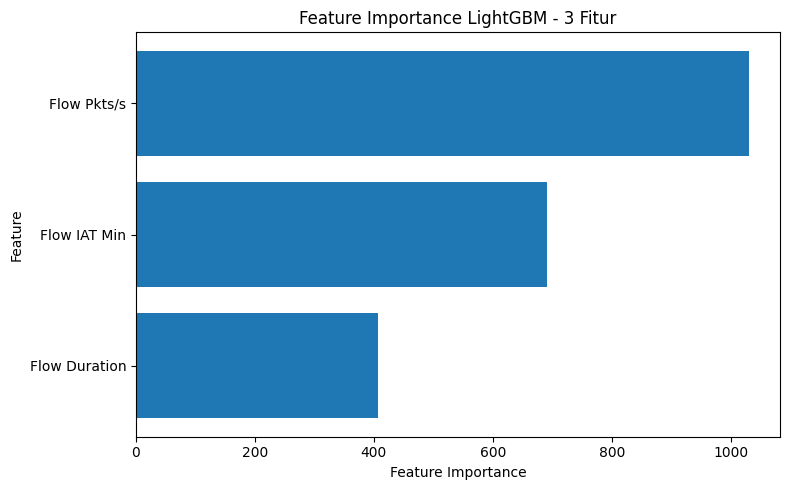

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance_3 = pd.DataFrame({
    "Feature": X_train_3_smote.columns,
    "Importance": model_lgbm_temporal_3.feature_importances_
})

# Urutkan dari importance terbesar
feature_importance_3 = feature_importance_3.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance LightGBM 3 Fitur")
print("--------------------------------")
print(feature_importance_3)

# ============================================
# VISUALISASI FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_3["Feature"],
    feature_importance_3["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance LightGBM - 3 Fitur")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()